In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

/home/yz4d3h/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/yz4d3h/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/home/yz4d3h/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [165]:
"""
df = pd.read_csv("/home/kzb068/Documents/ProcessedData/ParkingLot5RightFront.csv")
df2 = pd.read_csv("/home/kzb068/Documents/ProcessedData/ParkingLot3RightFront.csv")
df3 = pd.read_csv("/home/kzb068/Documents/ProcessedData/ParkingLot4RightFront.csv")
df4 = pd.read_csv("/home/kzb068/Documents/ProcessedData/ParkingLot2RightFront.csv")
df5 = pd.read_csv("/home/kzb068/Documents/ProcessedData/ParkingLot1RightFront.csv")
df6 = pd.read_csv("/home/kzb068/Documents/ProcessedData/ParkingLot1LeftFront.csv")
df7 = pd.read_csv("/home/kzb068/Documents/ProcessedData/ParkingLot2LeftFront.csv")
df8 = pd.read_csv("/home/kzb068/Documents/ProcessedData/ParkingLot3LeftFront.csv")
df9 = pd.read_csv("/home/kzb068/Documents/ProcessedData/Dist1.csv")
df10 = pd.read_csv("/home/kzb068/Documents/ProcessedData/Dist2.csv")
df = pd.concat([df, df2, df3, df4, df5, df6, df7, df8, df9, df10])

df.to_csv("/home/kzb068/Documents/ProcessedData/Merged.csv")
"""

# df_follow = pd.read_csv("/home/kzb068/Documents/ProcessedData/FollowBehind.csv")
# df_LeftToFarTurn = pd.read_csv("/home/kzb068/Documents/ProcessedData/LeftToFarTurn.csv")
# df_LeftToRight = pd.read_csv("/home/kzb068/Documents/ProcessedData/LeftToRight.csv")
# df_LeftToRight2 = pd.read_csv("/home/kzb068/Documents/ProcessedData/LeftToRight2.csv")
# df_LeftToTurnClose = pd.read_csv("/home/kzb068/Documents/ProcessedData/LeftToTurnClose.csv")
# df_RightToCloseTurn2 = pd.read_csv("/home/kzb068/Documents/ProcessedData/RightToCloseTurn2.csv")
# df_RightToCloseTurn = pd.read_csv("/home/kzb068/Documents/ProcessedData/RightToCloseTurn.csv")
# df_RightToLeft = pd.read_csv("/home/kzb068/Documents/ProcessedData/RightToLeft.csv")

df_RightToLeft = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc1/sc1_RightToLeft_filtered.csv")
df_RightToCloseTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc3/sc3_RightToCloseTurn_filtered.csv")
df_LeftToCloseTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc4/sc4_LeftToCloseTurn_filtered.csv")
df_LeftToFarTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc5/sc5_LeftToFarTurn_filtered.csv")
df_FromFront = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc6/sc6_FromFront_filtered.csv")
df_FromFrontLeft = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc7/sc7_FromFrontLeft_filtered.csv")

df_RightToLeftFusion = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc1/sc1_RightToLeft_fusion.csv")
# df_RightToCloseTurnFusion = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc3/sc3_RightToCloseTurn_fusion.csv")
# df_LeftToCloseTurnFusion = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc4/sc4_LeftToCloseTurnFusion.csv")
# df_LeftToFarTurnFusion = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc5/sc5_LeftToFarTurnFusion.csv")
# df_FromFrontFusion = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc6/sc6_FromFrontFusion.csv")
# df_FromFrontLeftFusion = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc7/sc7_FromFrontLeftFusion.csv")

#df_static= pd.read_csv("/home/kzb068/Documents/ProcessedData/Merged.csv")
df = pd.concat([df_RightToLeft,df_RightToCloseTurn, df_LeftToCloseTurn, df_LeftToFarTurn, df_FromFront,
                df_FromFrontLeft])
# df = pd.concat([df_RightToLeft,df_RightToCloseTurn])
# df_fusion = pd.concat([df_RightToLeftFusion, df_RightToCloseTurnFusion,df_LeftToCloseTurnFusion, df_LeftToFarTurnFusion, df_FromFrontFusion,
#                        df_FromFrontLeftFusion])
df_fusion = df_RightToLeftFusion
df_fusion_subset = df_fusion
df_subset = df

#print(df.columns)

def calc_num_lat_stdev(x):
    #print(x)
    stdev = math.sqrt(x["lat covariance"])+0.25
    accuracy = x["lat error"]-1.5
    if accuracy < 0:
        return 0
    num_stdev = accuracy/stdev
    return  int(num_stdev)+1

def calc_num_lon_stdev(x):
    stdev = math.sqrt(x["lon covariance"])+0.25
    accuracy = x["lon error"]-2.5
    if accuracy < 0:
        return 0
    num_stdev = accuracy/stdev
    return  int(num_stdev)+1


colors = [' ', [1,0,0],[0,0,1],[0,1,0],[1,0,1]]
markers = ['.', 'o', '^', 's', 'P','p','1','*','+','x','D']
group = [' ',"LRR", "FCM", "L-SRR", "R-SRR"]

# Flipped Until data is reprocessed to fix axis
#df['lat offset from ego (m)']= -df['lat offset from ego (m)']
df_subset['lat offset from ego (m)']= -df_subset['lat offset from ego (m)']
#df['lat_vel w.r.t ego (m/s)']= -df['lat_vel w.r.t ego (m/s)']
df_subset['interpolated ground truth x in m'] = -df_subset['interpolated ground truth x in m']
#df['interpolated x velocity in m/s'] = -df['interpolated x velocity in m/s']
df_subset["marker"] = df_subset.apply(lambda x: markers[x["sensor_id"]], axis=1)
df_subset["sensor"] = df_subset.apply(lambda x: group[x["sensor_id"]], axis=1)
df_subset["color"] = df_subset.apply(lambda x: colors[x["sensor_id"]], axis=1)
df_subset['lat actual error'] = df_subset['lat offset from ego (m)'] - df_subset['interpolated ground truth x in m']
df_subset['lon actual error'] = df_subset['lon offset from ego (m)'] - df_subset['interpolated ground truth y in m']
df_subset['lat_vel actual error'] = df_subset['lat_vel w.r.t ego (m/s)'] - df_subset['interpolated x velocity in m/s']
df_subset['lon_vel actual error'] = df_subset['lon_vel w.r.t. ego (m/s)'] - df_subset['interpolated y velocity in m/s']

df["marker"] = df.apply(lambda x: markers[x["sensor_id"]], axis=1)
df["sensor"] = df.apply(lambda x: group[x["sensor_id"]], axis=1)
df["color"] = df.apply(lambda x: colors[x["sensor_id"]], axis=1)
df["lat_stdevs"] = df.apply(lambda x: calc_num_lat_stdev(x), axis=1)
df["lon_stdevs"] = df.apply(lambda x: calc_num_lon_stdev(x), axis=1)
print(df['interpolated ground truth x in m'].corr(df['lat error']))
df['lat actual error'] = df['lat offset from ego (m)'] - df['interpolated ground truth x in m']
df['lon actual error'] = df['lon offset from ego (m)'] - df['interpolated ground truth y in m']
df['lat_vel actual error'] = df['lat_vel w.r.t ego (m/s)'] - df['interpolated x velocity in m/s']
df['lon_vel actual error'] = df['lon_vel w.r.t. ego (m/s)'] - df['interpolated y velocity in m/s']

df_fusion_subset['lat actual error'] = df_fusion_subset['Lat'] - df_fusion_subset['GT Lat']
df_fusion_subset['lon actual error'] = df_fusion_subset['Lon'] - df_fusion_subset['GT Lon']
df_fusion_subset['lat_vel actual error'] = df_fusion_subset['Lat_Vel'] - df_fusion_subset['GT Lat_Vel']
df_fusion_subset['lon_vel actual error'] = df_fusion_subset['Lon_Vel'] - df_fusion_subset['GT Lon_Vel']

df


0.05301008388031653


,TimeStamp in ms since epoch,sensor_id,track_id,track_status,confidence,object_type,lat offset from ego (m),lon offset from ego (m),lat_vel w.r.t ego (m/s),lon_vel w.r.t. ego (m/s),...,test_id,marker,sensor,color,lat actual error,lon actual error,lat_vel actual error,lon_vel actual error,lat_stdevs,lon_stdevs
0,1749564567273,4,29,3,2,False,64.000,25.375,0.625,-1.500,...,RightToLeft,P,R-SRR,"[1, 0, 1]",-2.791530,-3.425800,-0.259557,-0.652100,2,1
1,1749564567323,4,29,3,2,False,64.000,25.500,0.750,-1.500,...,RightToLeft,P,R-SRR,"[1, 0, 1]",-2.747302,-3.258405,-0.134557,-0.652100,2,1
2,1749564567374,4,29,3,2,False,64.000,25.625,0.750,-1.500,...,RightToLeft,P,R-SRR,"[1, 0, 1]",-2.702190,-3.090162,-0.134557,-0.652100,2,1
3,1749564567423,4,29,3,2,False,64.000,25.625,0.750,-1.625,...,RightToLeft,P,R-SRR,"[1, 0, 1]",-2.658847,-3.048615,-0.134557,-0.777100,2,1
4,1749564567474,4,29,3,2,False,64.000,25.750,0.750,-1.500,...,RightToLeft,P,R-SRR,"[1, 0, 1]",-2.613734,-2.880372,-0.134557,-0.652100,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1222,1749564948936,4,25,3,2,False,8.875,15.875,-7.875,-3.125,...,FromFrontLeft,P,R-SRR,"[1, 0, 1]",1.140387,-1.851141,-3.128129,-2.017561,0,0
1223,1749564948946,1,57,3,3,False,10.375,17.375,-7.125,-3.750,...,FromFrontLeft,o,LRR,"[1, 0, 0]",2.592918,-0.340067,-2.378129,-2.642561,3,0
1224,1749564948987,4,25,3,2,False,9.125,15.750,-8.000,-3.125,...,FromFrontLeft,P,R-SRR,"[1, 0, 1]",1.151589,-1.924521,-3.359356,-2.174289,0,0
1225,1749564949006,1,57,3,3,False,10.625,17.000,-7.125,-3.750,...,FromFrontLeft,o,LRR,"[1, 0, 0]",2.563417,-0.656457,-2.484356,-2.799289,3,0


In [458]:
def print_stats(prefix, df_temp):
    print(f"{prefix} Lat Actual Error Mean: {df_temp['lat actual error'].mean():.2f}")
    print(f"{prefix} Lat Actual Error STDEV: {df_temp['lat actual error'].std():.2f}")
    print(f"{prefix} Lat Actual Error Median: {df_temp['lat actual error'].median():.2f}")
    print()
    # print(f"{prefix} Lat Actual Error Min: {df_temp['lat actual error'].min()}")
    # print(f"{prefix} Lat Actual Error Max: {df_temp['lat actual error'].max()}")

    print(f"{prefix} Lon Actual Error Mean: {df_temp['lon actual error'].mean():.2f}")
    print(f"{prefix} Lat Actual Error STDEV: {df_temp['lon actual error'].std():.2f}")
    print(f"{prefix} Lon Actual Error Median: {df_temp['lon actual error'].median():.2f}")
    print()
    # print(f"{prefix} Lon Actual Error Min: {df_temp['lon actual error'].min()}")
    # print(f"{prefix} Lon Actual Error Max: {df_temp['lon actual error'].max()}")

    print(f"{prefix} Lat_Vel Actual Error Mean: {df_temp['lat_vel actual error'].mean():.2f}")
    print(f"{prefix} Lat_Vel Actual Error STDEV: {df_temp['lat_vel actual error'].std():.2f}")
    print(f"{prefix} Lat_Vel Actual Error Median: {df_temp['lat_vel actual error'].median():.2f}")
    print()
    # print(f"{prefix} Lat_Vel Actual Error Min: {df_temp['lat_vel actual error'].min()}")
    # print(f"{prefix} Lat_Vel Actual Error Max: {df_temp['lat_vel actual error'].max()}")

    print(f"{prefix} Lon_Vel Actual Error Mean: {df_temp['lon_vel actual error'].mean():.2f}")
    print(f"{prefix} Lon_Vel Actual Error STDEV: {df_temp['lon_vel actual error'].std():.2f}")
    print(f"{prefix} Lon_Vel Actual Error Median: {df_temp['lon_vel actual error'].median():.2f}")
    # print(f"{prefix} Lon_Vel Actual Error Min: {df_temp['lon_vel actual error'].min()}")
    # print(f"{prefix} Lon_Vel Actual Error Max: {df_temp['lon_vel actual error'].max()}")

df_LRR = selected = df[df['sensor'] =='LRR']
df_LSRR = selected = df[df['sensor'] =='L-SRR']
df_RSRR = selected = df[df['sensor'] =='R-SRR']
df_FCM = selected = df[df['sensor'] =='FCM']

print_stats("LRR", df_LRR)
print()
print_stats("FCM", df_FCM)
print()
print_stats("R-SRR", df_RSRR)
print()
print_stats("LSRR", df_LSRR)
print()



LRR Lat Actual Error Mean: 2.42
LRR Lat Actual Error STDEV: 1.45
LRR Lat Actual Error Median: 2.92

LRR Lon Actual Error Mean: -2.34
LRR Lat Actual Error STDEV: 1.03
LRR Lon Actual Error Median: -2.03

LRR Lat_Vel Actual Error Mean: 0.09
LRR Lat_Vel Actual Error STDEV: 1.09
LRR Lat_Vel Actual Error Median: 0.03

LRR Lon_Vel Actual Error Mean: -0.03
LRR Lon_Vel Actual Error STDEV: 0.79
LRR Lon_Vel Actual Error Median: 0.02

FCM Lat Actual Error Mean: 2.62
FCM Lat Actual Error STDEV: 0.75
FCM Lat Actual Error Median: 2.63

FCM Lon Actual Error Mean: -0.72
FCM Lat Actual Error STDEV: 3.94
FCM Lon Actual Error Median: -2.01

FCM Lat_Vel Actual Error Mean: 0.00
FCM Lat_Vel Actual Error STDEV: 0.43
FCM Lat_Vel Actual Error Median: 0.04

FCM Lon_Vel Actual Error Mean: 0.07
FCM Lon_Vel Actual Error STDEV: 1.10
FCM Lon_Vel Actual Error Median: -0.23

R-SRR Lat Actual Error Mean: 3.21
R-SRR Lat Actual Error STDEV: 1.49
R-SRR Lat Actual Error Median: 3.51

R-SRR Lon Actual Error Mean: -2.88
R-SRR

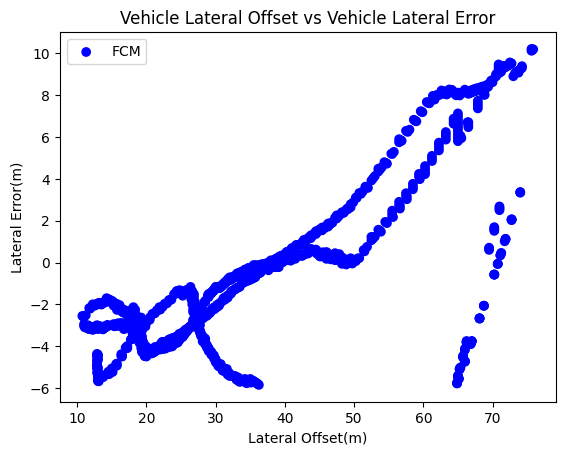

In [273]:
i = 0
for sensor, d in df_subset.groupby('sensor'):
    i+=1
    marker = markers[i]
    if sensor != "FCM":
        continue
    plt.scatter(x=d['lon offset from ego (m)'], y=d['lon actual error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Lateral Offset(m)")
plt.ylabel("Lateral Error(m)")
plt.title("Vehicle Lateral Offset vs Vehicle Lateral Error")
plt.legend()

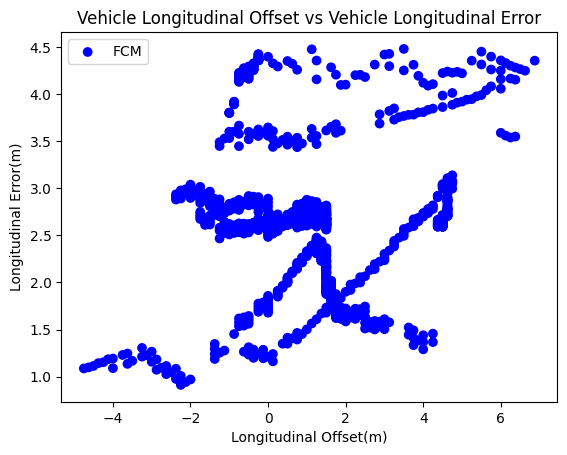

In [168]:
i = 0
for sensor, d in df.groupby('sensor'):
    i+=1
    marker = markers[i]
    if sensor != "FCM":
        continue
    plt.scatter(x=d['lat offset from ego (m)'], y=d['lat actual error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Longitudinal Offset(m)")
plt.ylabel("Longitudinal Error(m)")
plt.title("Vehicle Longitudinal Offset vs Vehicle Longitudinal Error")
plt.legend()

<Axes: xlabel='lat error', ylabel='lon error'>

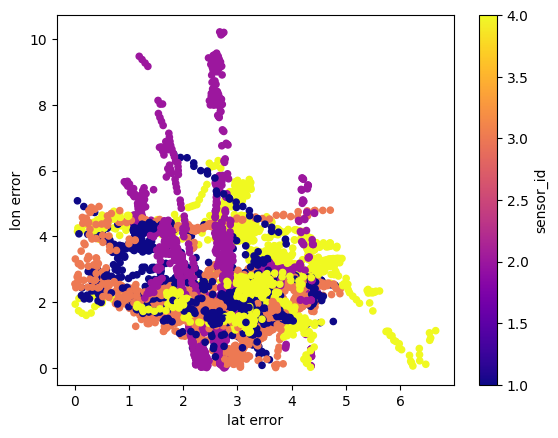

In [169]:
df.plot.scatter(x="lat error", y="lon error", c='sensor_id', colormap='plasma')

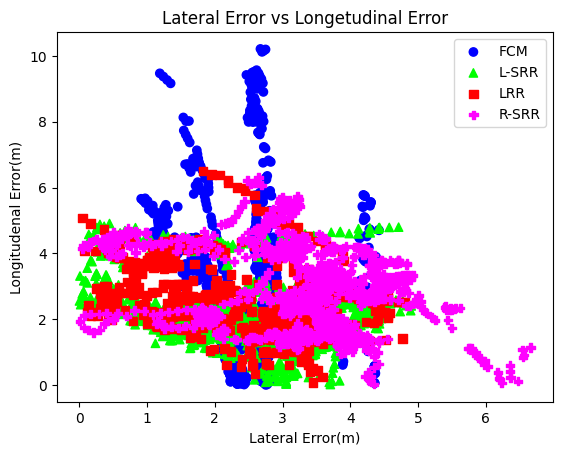

In [170]:
i = 0
for sensor, d in df.groupby('sensor'):
    i+=1
    #if sensor == "FCM":
    #    continue
    marker = markers[i]
    plt.scatter(x=d['lat error'], y=d['lon error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Lateral Error(m)")
plt.ylabel("Longitudenal Error(m)")
plt.title("Lateral Error vs Longetudinal Error")
plt.legend()

Text(0.5, 1.0, 'Lateral Error vs Longetudinal Error')

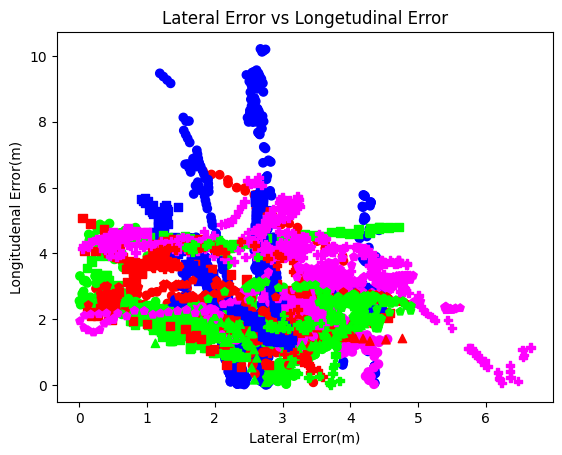

In [171]:
i = 0
for sensor, d in df.groupby('test_id'):
    i+=1
    #if sensor == "FCM":
    #    continue
    marker = markers[i]
    plt.scatter(x=d['lat error'], y=d['lon error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Lateral Error(m)")
plt.ylabel("Longitudenal Error(m)")
plt.title("Lateral Error vs Longetudinal Error")

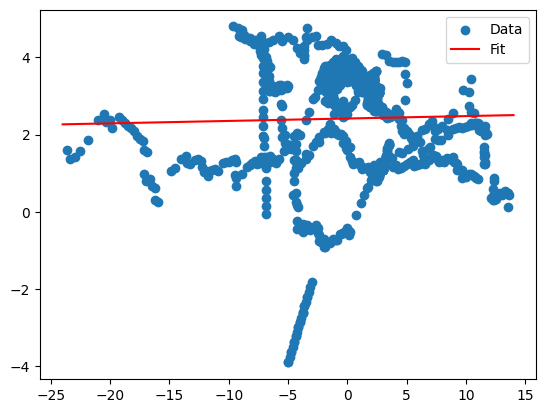

0.00628062194053014 2.4183405017470134
-2.8470791640314744e-12
1.4496479170725634
2.419053869245737
1.4507724901249546
0.024470459952141255


In [172]:
selected = df_subset[df_subset['sensor'] =='LRR']
col1 = 'lat offset from ego (m)'
col2 = 'lat actual error'
# col1 = 'lon offset from ego (m)'
# col2 = 'lon actual error'
# col1 = 'lat_vel w.r.t ego (m/s)'
# col2 = 'lat_vel actual error'
# col1 = 'lon_vel w.r.t. ego (m/s)'
# col2 = 'lon_vel actual error'
def func(x, a, b):
    return a * x + b
popt, pcov = curve_fit(func, selected[col1], selected[col2])
plt.scatter(selected[col1], selected[col2], label='Data')
plt.plot(range(int(selected[col1].min())-1,int(selected[col1].max())+2), func(np.arange(int(selected[col1].min())-1,int(selected[col1].max())+2), *popt), 'r-', label='Fit')
plt.legend()
plt.show()
print(*popt)

def lon_error_func(x):
    return x[col2] - func(x[col1], *popt)
errors = []
for index, row in selected.iterrows():
    errors.append(lon_error_func(row))

print(np.mean(errors))
print(np.std(errors))
print(selected[col2].mean())
print(selected[col2].std())
print(selected[col1].corr(selected[col2]))

In [173]:
0.022411592472858764

0.022411592472858764

In [174]:
print("LRR")
print("lat: 0.024470459952141255")
print("lon: 0.22550698478578485")
print("lat_vel: 0.21922520528028894")
print("lon_vel: 0.11834527366802658")

print("FCM")
print("lat: 0.14634506069837333")
print("lon: 0.7807440787662133")
print("lat_vel: 0.11658857475888673")
print("lon_vel: 0.2476125864609598")

print("L-SRR")
print("lat: 0.03702274732303747")
print("lon: -0.18989050128421134")
print("lat_vel: 0.05907057718107386")
print("lon_vel: -0.05681637723693267")

print("R-SRR")
print("lat: -0.44385974525727384")
print("lon: 0.2663856111326767")
print("lat_vel: 0.38601976862599796")
print("lon_vel: 0.1630066281900743")

LRR
lat: 0.024470459952141255
lon: 0.22550698478578485
lat_vel: 0.21922520528028894
lon_vel: 0.11834527366802658
FCM
lat: 0.14634506069837333
lon: 0.7807440787662133
lat_vel: 0.11658857475888673
lon_vel: 0.2476125864609598
L-SRR
lat: 0.03702274732303747
lon: -0.18989050128421134
lat_vel: 0.05907057718107386
lon_vel: -0.05681637723693267
R-SRR
lat: -0.44385974525727384
lon: 0.2663856111326767
lat_vel: 0.38601976862599796
lon_vel: 0.1630066281900743


0.1630066281900743

/tmp/ipykernel_2549759/3347828137.py:19: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, selected[col1], selected[col2])


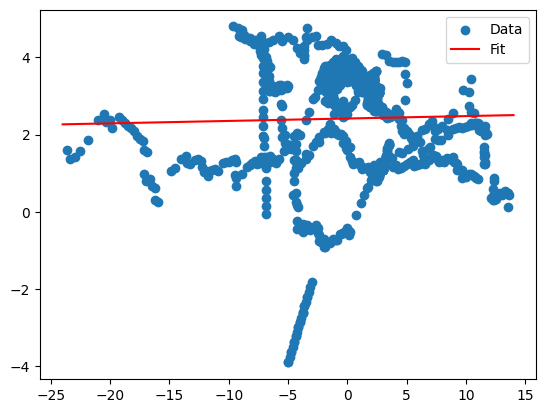

0.00628062194053014 2.4183405017470134 1.0
-2.8470791640314744e-12
1.4496479170725634
*****
2.419053869245737
1.4507724901249546
0.024470459952141255
13.625


In [175]:
selected = df_subset[df_subset['sensor'] =='LRR']
col1 = 'lat offset from ego (m)'
# col1 = 'lon_vel w.r.t. ego (m/s)'
col2 = 'lat actual error'
# col2 = 'lon_vel actual error'
def func(x, a, b, c):
    return a * x + b

# threshold = 63.5

# # Filter the selected DataFrame directly
# selected = selected[selected[col1] < threshold]
# selected = selected[-5 < selected[col1]]

# # Now extract the arrays
# selected[col1] = selected[col1].to_numpy()
# selected[col2] = selected[col2].to_numpy()

popt, pcov = curve_fit(func, selected[col1], selected[col2])
plt.scatter(selected[col1], selected[col2], label='Data')
plt.plot(range(int(selected[col1].min())-1,int(selected[col1].max())+2), func(np.arange(int(selected[col1].min())-1,int(selected[col1].max())+2), *popt), 'r-', label='Fit')
plt.legend()
plt.show()
print(*popt)

def lon_error_func(x):
    return x[col2] - func(x[col1], *popt)
errors = []
for index, row in selected.iterrows():
    errors.append(lon_error_func(row))

print(np.mean(errors))
print(np.std(errors))
print("*****")
print(selected[col2].mean())
print(selected[col2].std())
print(selected[col1].corr(selected[col2]))
print(max(selected[col1]))

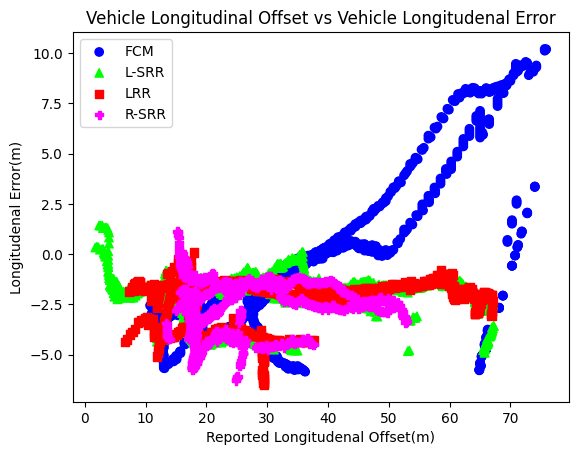

In [176]:
i = 0
for sensor, d in df.groupby('sensor'):
    i+=1
    marker = markers[i]
    #if sensor != "R-SRR":
    #    continue
    plt.scatter(x=d['lon offset from ego (m)'], y=d['lon actual error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Reported Longitudenal Offset(m)")
plt.ylabel("Longitudenal Error(m)")
plt.title("Vehicle Longitudinal Offset vs Vehicle Longitudenal Error")
plt.legend()

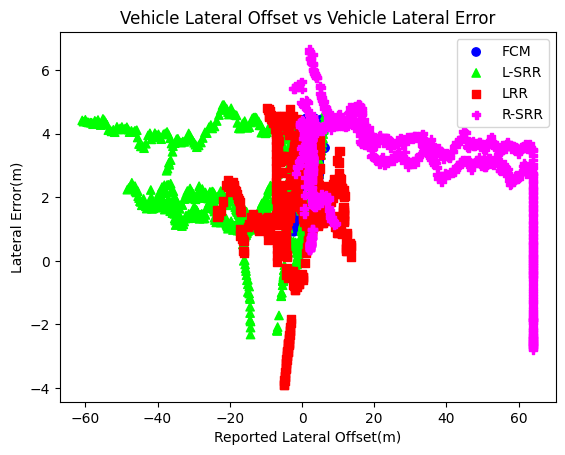

In [177]:
i = 0
for sensor, d in df.groupby('sensor'):
    i+=1
    marker = markers[i]
    #if sensor != "R-SRR":
    #    continue
    plt.scatter(x=d['lat offset from ego (m)'], y=d['lat actual error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Reported Lateral Offset(m)")
plt.ylabel("Lateral Error(m)")
plt.title("Vehicle Lateral Offset vs Vehicle Lateral Error")
plt.legend()

<Axes: xlabel='lat error', ylabel='interpolated ground truth x in m'>

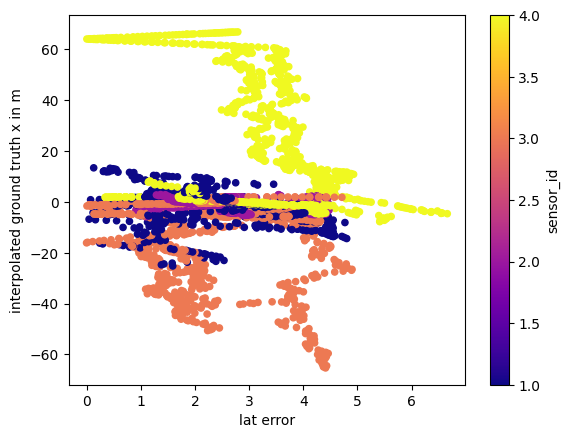

In [178]:
df.plot.scatter(x="lat error", y="interpolated ground truth x in m", c='sensor_id', colormap='plasma')

sensor_id
1    Axes(0.125,0.11;0.775x0.77)
2    Axes(0.125,0.11;0.775x0.77)
3    Axes(0.125,0.11;0.775x0.77)
4    Axes(0.125,0.11;0.775x0.77)
dtype: object

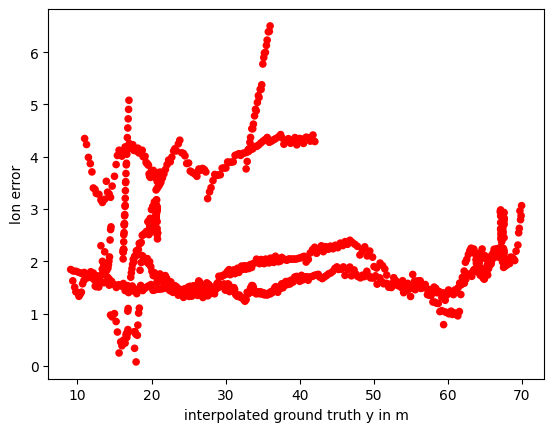

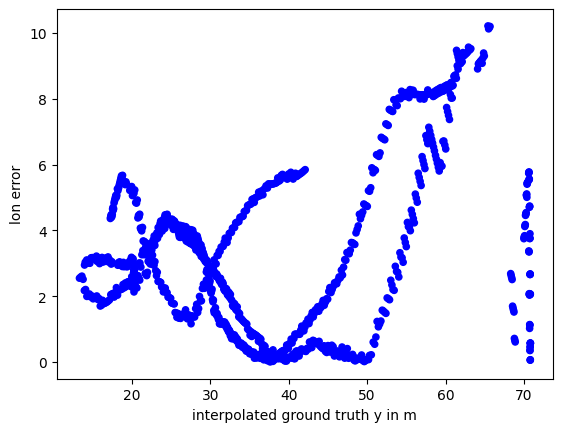

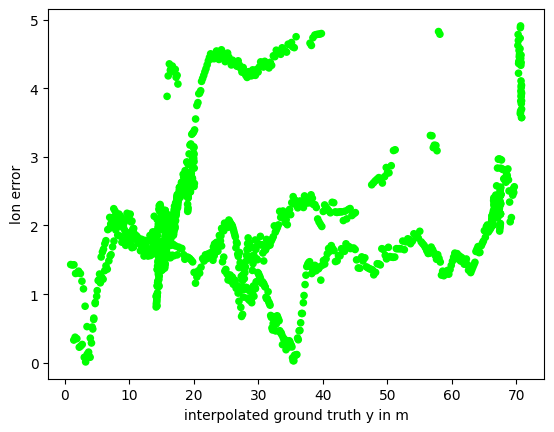

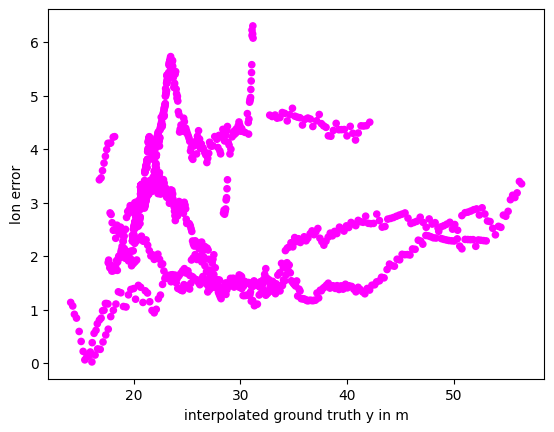

In [179]:
df.groupby('sensor_id').plot.scatter(x="interpolated ground truth y in m", y="lon error", c='color')

/home/yz4d3h/.local/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/home/yz4d3h/.local/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/home/yz4d3h/.local/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/home/yz4d3h/.local/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend

sensor_id
1    [[Axes(0.125,0.53;0.352273x0.35), Axes(0.54772...
2    [[Axes(0.125,0.53;0.352273x0.35), Axes(0.54772...
3    [[Axes(0.125,0.53;0.352273x0.35), Axes(0.54772...
4    [[Axes(0.125,0.53;0.352273x0.35), Axes(0.54772...
dtype: object

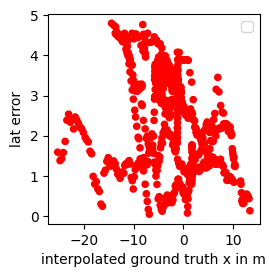

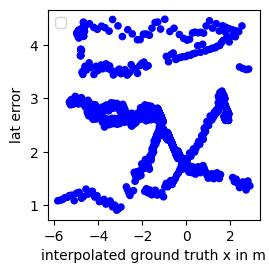

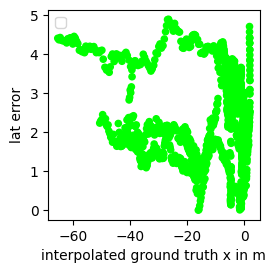

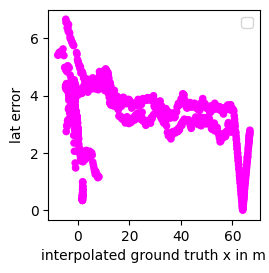

In [180]:
df.groupby('sensor_id').plot.scatter(x="interpolated ground truth x in m", y="lat error", c='color', subplots=True, layout=(2, 2), figsize=(6, 6), sharex=False)

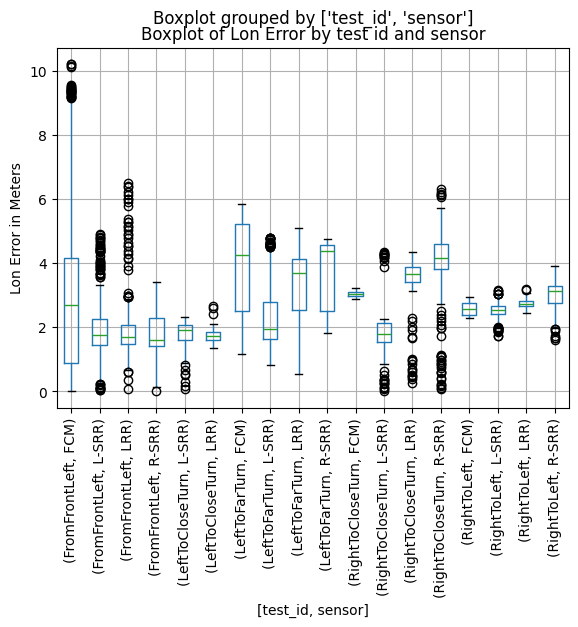

In [181]:
df.boxplot(column='lon error', by=['test_id', 'sensor'])
plt.title('Boxplot of Lon Error by test id and sensor')
plt.ylabel("Lon Error in Meters")
plt.xticks(rotation=90)
plt.show()

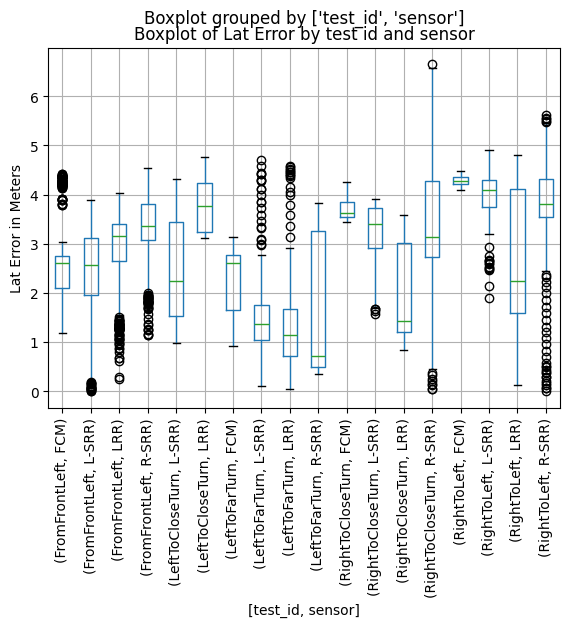

In [182]:
df.boxplot(column='lat error', by=['test_id', 'sensor'])
plt.title('Boxplot of Lat Error by test id and sensor')
plt.ylabel("Lat Error in Meters")
plt.xticks(rotation=90)
plt.show()

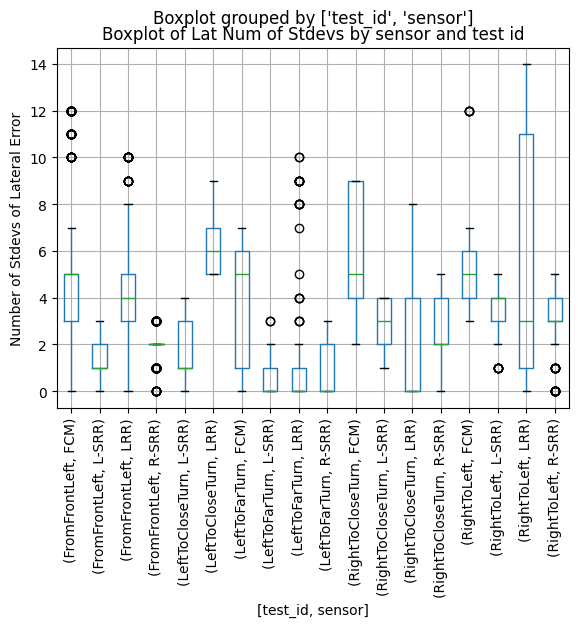

In [183]:
df.boxplot(column='lat_stdevs', by=['test_id', 'sensor'])
plt.title('Boxplot of Lat Num of Stdevs by sensor and test id')
plt.ylabel("Number of Stdevs of Lateral Error")
plt.xticks(rotation=90)
plt.show()

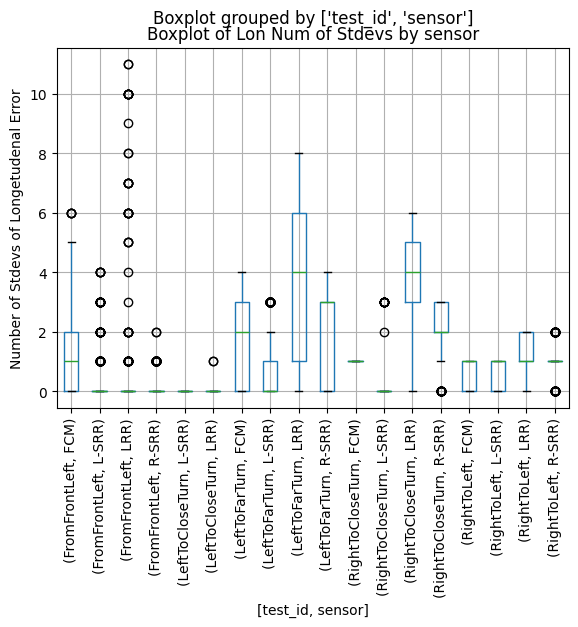

In [184]:
df.boxplot(column='lon_stdevs', by=['test_id', 'sensor'])
plt.title('Boxplot of Lon Num of Stdevs by sensor')
plt.ylabel("Number of Stdevs of Longetudenal Error")
plt.xticks(rotation=90)
plt.show()

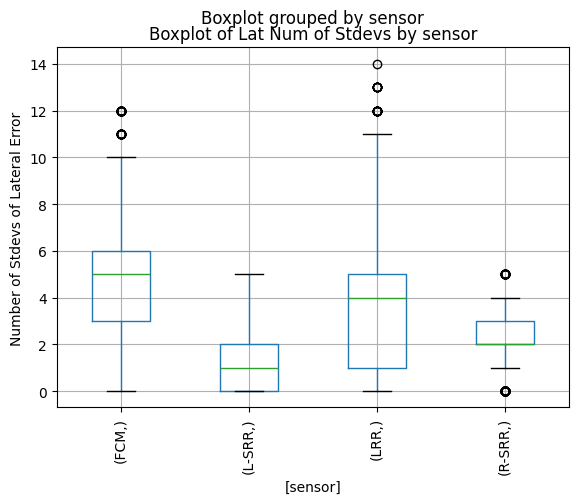

In [185]:
df.boxplot(column='lat_stdevs', by=['sensor'])
plt.title('Boxplot of Lat Num of Stdevs by sensor')
plt.ylabel("Number of Stdevs of Lateral Error")
plt.xticks(rotation=90)
plt.show()

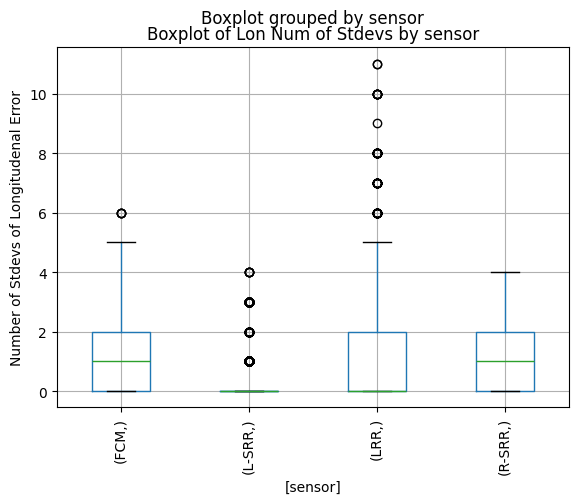

In [186]:
df.boxplot(column='lon_stdevs', by=['sensor'])
plt.title('Boxplot of Lon Num of Stdevs by sensor')
plt.ylabel("Number of Stdevs of Longitudenal Error")
plt.xticks(rotation=90)
plt.show()

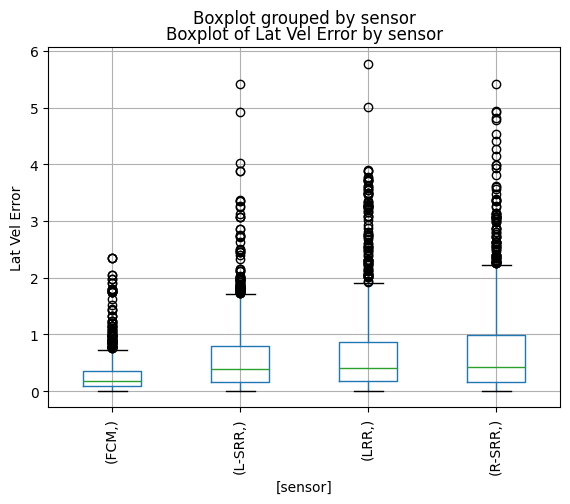

In [187]:
df.boxplot(column='lat vel error', by=['sensor'])
plt.title('Boxplot of Lat Vel Error by sensor')
plt.ylabel("Lat Vel Error")
plt.xticks(rotation=90)
plt.show()

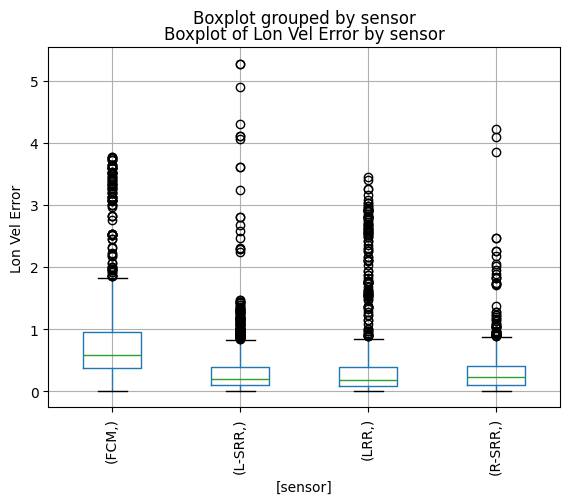

In [188]:
df.boxplot(column='lon vel error', by=['sensor'])
plt.title('Boxplot of Lon Vel Error by sensor')
plt.ylabel("Lon Vel Error")
plt.xticks(rotation=90)
plt.show()

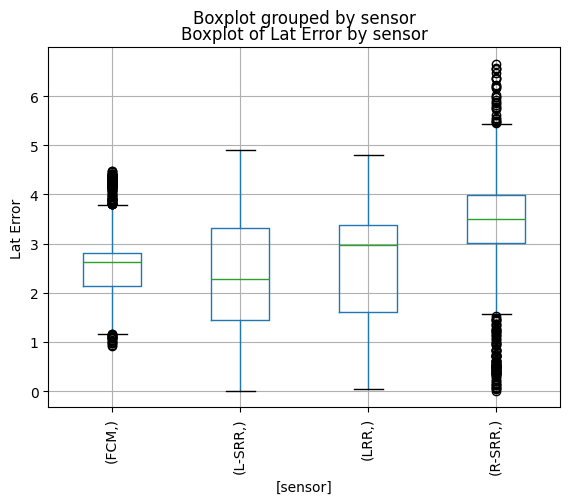

In [189]:
df.boxplot(column='lat error', by=['sensor'])
plt.title('Boxplot of Lat Error by sensor')
plt.ylabel("Lat Error")
plt.xticks(rotation=90)
plt.show()

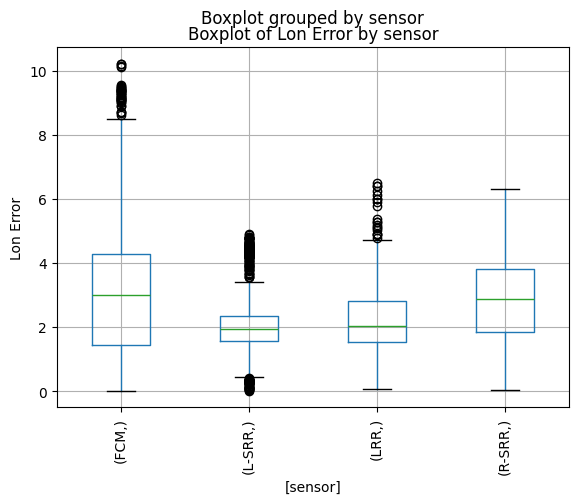

In [190]:
df.boxplot(column='lon error', by=['sensor'])
plt.title('Boxplot of Lon Error by sensor')
plt.ylabel("Lon Error")
plt.xticks(rotation=90)
plt.show()

NameError: name 'df_LeftToFarTurnFusion' is not defined

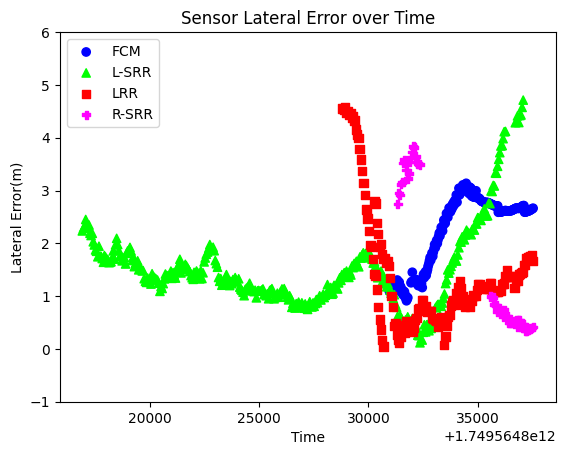

In [191]:
selected_rows = df[df['test_id'] =='LeftToFarTurn']
i = 0
for sensor, d in selected_rows.groupby('sensor'):
    i+=1
    marker = markers[i]
    #if sensor == "FCM":
    #    continue
    plt.scatter(x=d['TimeStamp in ms since epoch'], y=d['lat error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Time")
plt.ylabel("Lateral Error(m)")
plt.yticks([-1, 0, 1, 2, 3, 4, 5, 6])
plt.title("Sensor Lateral Error over Time")
plt.legend()

df_LeftToFarTurnFusion.plot.line(x="time", y="Error Lat")
plt.title("Fused Lateral Error over Time")
plt.ylabel("Lateral Error(m)")
plt.yticks([-1, 0, 1, 2, 3, 4, 5, 6])
plt.xlabel("Time")

In [ ]:
selected_rows = df[df['test_id'] =='LeftToFarTurn']
i = 0
for sensor, d in selected_rows.groupby('sensor'):
    i+=1
    marker = markers[i]
    #if sensor == "FCM":
    #    continue
    plt.scatter(x=d['TimeStamp in ms since epoch'], y=d['lon error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Time")
plt.ylabel("Longitudinal Error(m)")
plt.title("Sensor Longitudinal Error over Time")
plt.yticks([0, 2, 4, 6, 8, 10, 12])
plt.legend()

df_LeftToFarTurnFusion.plot.line(x="time", y="Error Lon")
plt.title("Fused Longitudinal Error over Time")
plt.yticks([0, 2, 4, 6, 8, 10, 12])
plt.ylabel("Longitudinal Error(m)")
plt.xlabel("Time")

In [ ]:
df_fusion.hist(column="Error Lat", bins=20)
plt.xlabel("Error in M")
plt.ylabel("Occurances")
plt.title("Fused Lateral Error")

In [ ]:
df_fusion.hist(column="Error Lon", bins=20)
plt.xlabel("Error in M")
plt.ylabel("Occurances")
plt.title("Fused Longitudinal Error")

In [ ]:
df_fusion.boxplot(column="Error Lat")


In [ ]:
df_fusion.boxplot(column="Error Lon")

In [ ]:
plt.scatter(x=df_fusion['GT Lon'], y=df_fusion['Error Lon'])
plt.xlabel("Longitudinal Offset(m)")
plt.ylabel("Longitudinal Error(m)")
plt.title("Fused Longitudinal Error vs Longitudinal Offset")

In [ ]:
plt.scatter(x=df_fusion['GT Lat'], y=df_fusion['Error Lat'])
plt.xlabel("Lateral Offset(m)")
plt.ylabel("Lateral Error(m)")
plt.title("Fused Lateral Error vs Lateral Offset")

# Velocity

In [ ]:
df.boxplot(column='lon vel error', by='sensor')
print(df['lon vel error'].mean())
print(df['lon vel error'].std())
print(df['lon vel error'].median())
print(df['lon vel error'].min())
print(df['lon vel error'].max())

In [ ]:
df.boxplot(column='lat vel error', by='sensor')
print(df['lat vel error'].mean())
print(df['lat vel error'].std())
print(df['lat vel error'].median())
print(df['lat vel error'].min())
print(df['lat vel error'].max())

In [ ]:
i = 0
for sensor, d in df.groupby('sensor'):
    i+=1
    marker = markers[i]
    plt.scatter(x=d['interpolated x velocity in m/s'], y=d['lat vel error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Lateral Velocity(m/s)")
plt.ylabel("Lateral Velocity Error(m/s)")
plt.title("Lateral Velocity vs Lateral Velocity Error")
plt.legend()

In [ ]:
i = 0
for sensor, d in df.groupby('sensor'):
    i+=1
    if sensor != 'R-SRR':
        continue
    marker = markers[i]
    plt.scatter(x=d['interpolated x velocity in m/s'], y=d['lat vel error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Lateral Velocity(m/s)")
plt.ylabel("Lateral Velocity Error(m/s)")
plt.title("Lateral Velocity vs Lateral Velocity Error")
plt.legend()

In [ ]:
i = 0
for sensor, d in df.groupby('sensor'):
    i+=1
    if sensor != 'FCM':
        continue
    marker = markers[i]
    plt.scatter(x=d['interpolated y velocity in m/s'], y=d['lon vel error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Longitudinal Velocity(m/s)")
plt.ylabel("Longitudinal Velocity Error(m/s)")
plt.title("Longitudinal Velocity vs Longitudinal Velocity Error")
plt.legend()

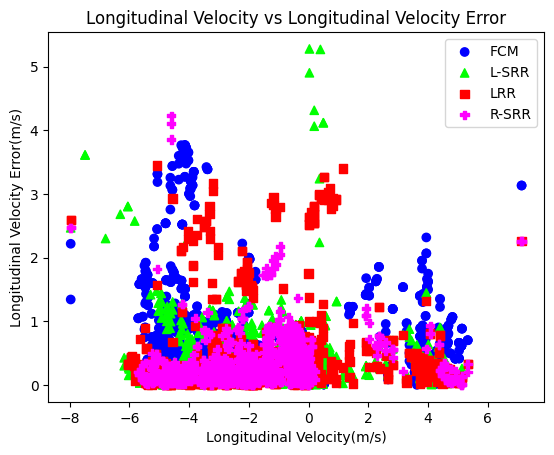

In [192]:
i = 0
for sensor, d in df.groupby('sensor'):
    i+=1
    marker = markers[i]
    plt.scatter(x=d['interpolated y velocity in m/s'], y=d['lon vel error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Longitudinal Velocity(m/s)")
plt.ylabel("Longitudinal Velocity Error(m/s)")
plt.title("Longitudinal Velocity vs Longitudinal Velocity Error")
plt.legend()

Text(0.5, 1.0, 'Fused Lateral Velocity Error')

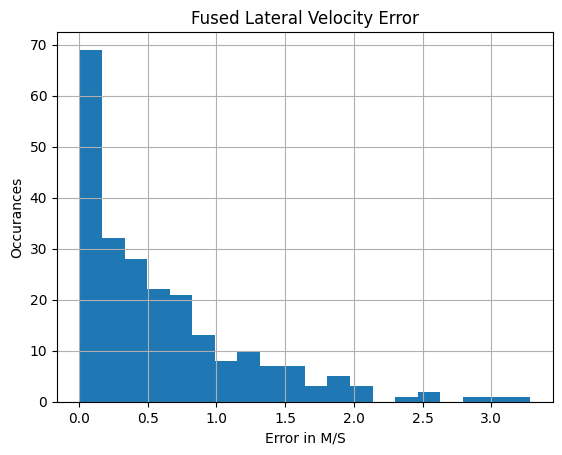

In [193]:
df_fusion.hist(column="Error Lat_Vel", bins=20)
plt.xlabel("Error in M/S")
plt.ylabel("Occurances")
plt.title("Fused Lateral Velocity Error")

Text(0.5, 1.0, 'Fused Longitudinal Velocity Error')

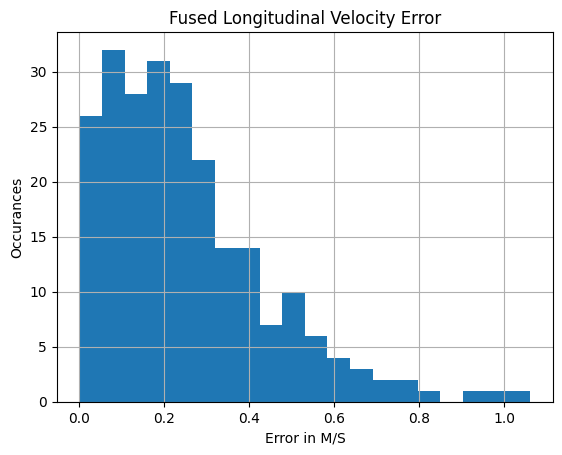

In [194]:
df_fusion.hist(column="Error Lon_Vel", bins=20)
plt.xlabel("Error in M/S")
plt.ylabel("Occurances")
plt.title("Fused Longitudinal Velocity Error")

In [195]:
print(df_fusion['Error Lon_Vel'].mean())
print(df_fusion['Error Lon_Vel'].std())
print(df_fusion['Error Lon_Vel'].median())
print(df_fusion['Error Lon_Vel'].min())
print(df_fusion['Error Lon_Vel'].max())

0.2529161111111111
0.19276612530969917
0.211588
0.000558
1.061834


In [196]:
print(df_fusion['Error Lat_Vel'].mean())
print(df_fusion['Error Lat_Vel'].std())
print(df_fusion['Error Lat_Vel'].median())
print(df_fusion['Error Lat_Vel'].min())
print(df_fusion['Error Lat_Vel'].max())

0.6181879145299146
0.6255583823888632
0.42028350000000003
0.004056
3.283558


Text(0.5, 1.0, 'Fused Lateral Velocity Error vs Lateral Velocity')

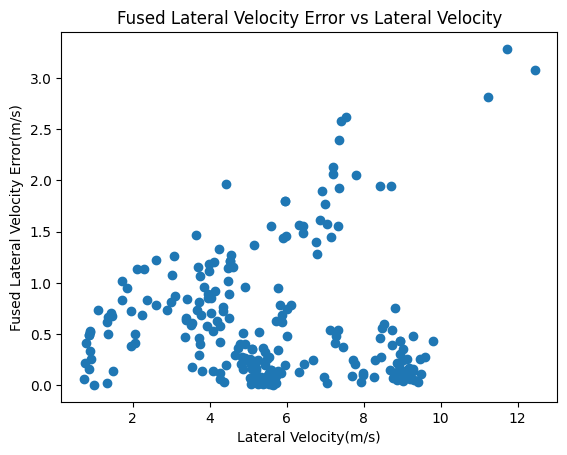

In [197]:
plt.scatter(x=df_fusion['GT Lat_Vel'], y=df_fusion['Error Lat_Vel'])
plt.xlabel("Lateral Velocity(m/s)")
plt.ylabel("Fused Lateral Velocity Error(m/s)")
plt.title("Fused Lateral Velocity Error vs Lateral Velocity")

Text(0.5, 1.0, 'Fused Longitudinal Velocity Error vs Longitudinal Velocity')

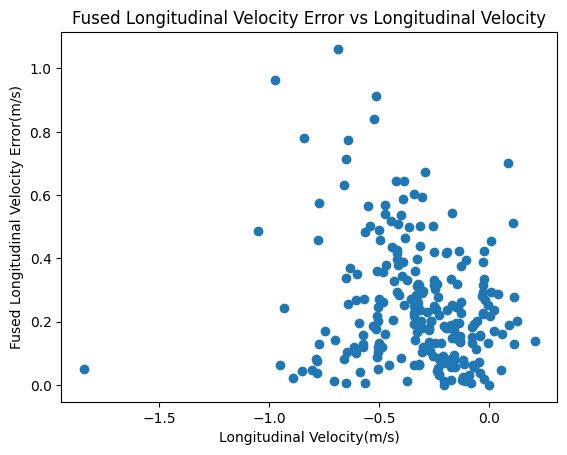

In [198]:
plt.scatter(x=df_fusion['GT Lon_Vel'], y=df_fusion['Error Lon_Vel'])
plt.xlabel("Longitudinal Velocity(m/s)")
plt.ylabel("Fused Longitudinal Velocity Error(m/s)")
plt.title("Fused Longitudinal Velocity Error vs Longitudinal Velocity")

NameError: name 'df_LeftToFarTurnFusion' is not defined

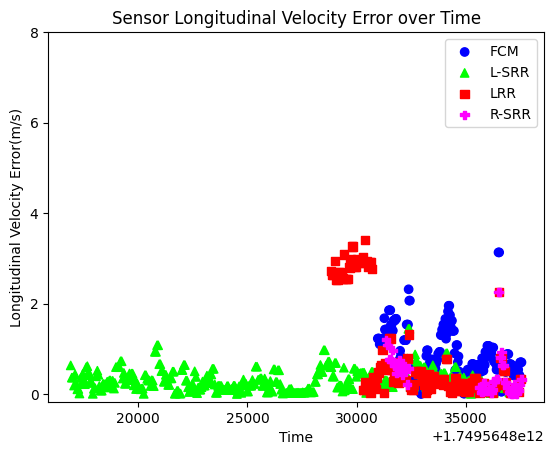

In [199]:
selected_rows = df[df['test_id'] =='LeftToFarTurn']
i = 0
for sensor, d in selected_rows.groupby('sensor'):
    i+=1
    marker = markers[i]
    #if sensor == "FCM":
    #    continue
    plt.scatter(x=d['TimeStamp in ms since epoch'], y=d['lon vel error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Time")
plt.ylabel("Longitudinal Velocity Error(m/s)")
plt.title("Sensor Longitudinal Velocity Error over Time")
plt.yticks([0, 2, 4, 6, 8])
plt.legend()

df_LeftToFarTurnFusion.plot.line(x="time", y="Error Lon_Vel")
plt.title("Fused Longitudinal Velocity Error over Time")
plt.yticks([0, 2, 4, 6, 8])
plt.ylabel("Longitudinal Velocity Error(m/s)")
plt.xlabel("Time")

NameError: name 'df_LeftToFarTurnFusion' is not defined

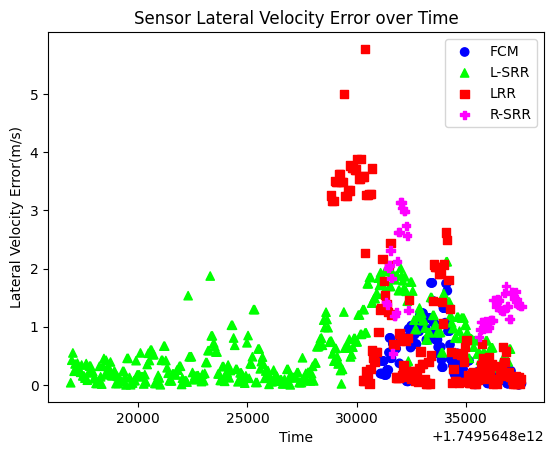

In [200]:
selected_rows = df[df['test_id'] =='LeftToFarTurn']
i = 0
for sensor, d in selected_rows.groupby('sensor'):
    i+=1
    marker = markers[i]
    #if sensor == "FCM":
    #    continue
    plt.scatter(x=d['TimeStamp in ms since epoch'], y=d['lat vel error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Time")
plt.ylabel("Lateral Velocity Error(m/s)")
plt.yticks([0, 1, 2, 3, 4, 5])
plt.title("Sensor Lateral Velocity Error over Time")
plt.legend()

df_LeftToFarTurnFusion.plot.line(x="time", y="Error Lat")
plt.title("Fused Lateral Velocity Error over Time")
plt.ylabel("Lateral Velocity Error(m/s)")
plt.yticks([0, 1, 2, 3, 4, 5])
plt.xlabel("Time")

/home/yz4d3h/.local/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/home/yz4d3h/.local/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/home/yz4d3h/.local/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/home/yz4d3h/.local/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend

sensor_id
1    [[Axes(0.125,0.53;0.352273x0.35), Axes(0.54772...
2    [[Axes(0.125,0.53;0.352273x0.35), Axes(0.54772...
3    [[Axes(0.125,0.53;0.352273x0.35), Axes(0.54772...
4    [[Axes(0.125,0.53;0.352273x0.35), Axes(0.54772...
dtype: object

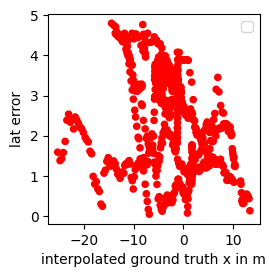

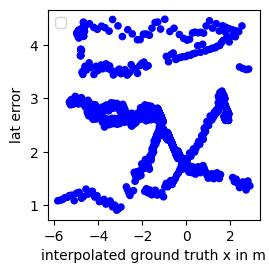

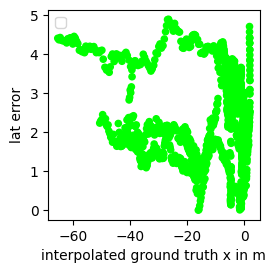

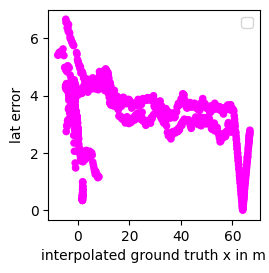

In [201]:
df.groupby('sensor_id').plot.scatter(x="interpolated ground truth x in m", y="lat error", c='color', subplots=True, layout=(2, 2), figsize=(6, 6), sharex=False)

# Pedestrian Data Processing

In [ ]:
df_Pedestrian = pd.read_csv("/home/kzb068/Documents/ProcessedData/Pedestrian2.csv")
colors = [' ', [1,0,0],[0,0,1],[0,1,0],[1,0,1]]
markers = ['.', 'o', '^', 's', 'P','p','1','*','+','x','D']
group = [' ',"LRR", "FCM", "L-SRR", "R-SRR"]
df_Pedestrian["marker"] = df_Pedestrian.apply(lambda x: markers[x["sensor_id"]], axis=1)
df_Pedestrian["sensor"] = df_Pedestrian.apply(lambda x: group[x["sensor_id"]], axis=1)
df_Pedestrian["color"] = df_Pedestrian.apply(lambda x: colors[x["sensor_id"]], axis=1)
df_Pedestrian['lat actual error'] = df_Pedestrian['lat offset from ego (m)'] - df_Pedestrian['interpolated ground truth x in m']
df_Pedestrian['lon actual error'] = df_Pedestrian['lon offset from ego (m)'] - df_Pedestrian['interpolated ground truth y in m']
df_Pedestrian['lat_vel actual error'] = df_Pedestrian['lat_vel w.r.t ego (m/s)'] - df_Pedestrian['interpolated x velocity in m/s']
df_Pedestrian['lon_vel actual error'] = df_Pedestrian['lon_vel w.r.t. ego (m/s)'] - df_Pedestrian['interpolated y velocity in m/s']
df_PedestrianFusion = pd.read_csv("/home/kzb068/Documents/ProcessedData/Pedestrian2Fusion.csv")



df_Pedestrian

In [ ]:
i = 0
for sensor, d in df_Pedestrian.groupby('sensor'):
    i+=1
    if sensor != "R-SRR":
        continue
    marker = markers[i]
    plt.scatter(x=d['interpolated ground truth x in m'], y=d['lat error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Lateral offset(m)")
plt.ylabel("Lateral Error(m)")
plt.title("Lateral Offset vs Lateral Error")
plt.legend()

In [ ]:
i = 0
for sensor, d in df_Pedestrian.groupby('sensor'):
    i+=1
    if sensor != "FCM":
        continue
    marker = markers[i]
    plt.scatter(x=d['interpolated ground truth y in m'], y=d['lon error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Longitudenal Offset(m)")
plt.ylabel("Longitudenal Error(m)")
plt.title("Longitudenal Offset vs Longetudinal Error")
plt.legend()

In [ ]:
df_Pedestrian.groupby('sensor_id').plot.scatter(x="interpolated ground truth x in m", y="lat error", c='color', subplots=True, layout=(2, 2), figsize=(6, 6), sharex=False)

In [ ]:
df_Pedestrian.groupby('sensor_id').plot.scatter(x="interpolated ground truth y in m", y="lon error", c='color', subplots=True, layout=(2, 2), figsize=(6, 6), sharex=False)

In [ ]:
filtered_df = df_Pedestrian.loc[df_Pedestrian["lon error"] > 3]

In [ ]:
filtered_df

In [ ]:
df_Pedestrian.boxplot(column='lon error', by='sensor')
plt.ylabel("Longitudenal Error(m)")

In [ ]:
df_Pedestrian.boxplot(column='lat error', by='sensor')
plt.ylabel("Lateral Error(m)")

In [ ]:
print(df_PedestrianFusion['Error Lat_Vel'].mean())
print(df_PedestrianFusion['Error Lat_Vel'].std())
print(df_PedestrianFusion['Error Lat_Vel'].median())
print(df_PedestrianFusion['Error Lat_Vel'].min())
print(df_PedestrianFusion['Error Lat_Vel'].max())

In [ ]:
print(df_PedestrianFusion['Error Lon_Vel'].mean())
print(df_PedestrianFusion['Error Lon_Vel'].std())
print(df_PedestrianFusion['Error Lon_Vel'].median())
print(df_PedestrianFusion['Error Lon_Vel'].min())
print(df_PedestrianFusion['Error Lon_Vel'].max())

In [ ]:
print(df_PedestrianFusion['Error Lat'].mean())
print(df_PedestrianFusion['Error Lat'].std())
print(df_PedestrianFusion['Error Lat'].median())
print(df_PedestrianFusion['Error Lat'].min())
print(df_PedestrianFusion['Error Lat'].max())

In [ ]:
print(df_PedestrianFusion['Error Lon'].mean())
print(df_PedestrianFusion['Error Lon'].std())
print(df_PedestrianFusion['Error Lon'].median())
print(df_PedestrianFusion['Error Lon'].min())
print(df_PedestrianFusion['Error Lon'].max())

In [ ]:
df_PedestrianFusion.hist(column="Error Lon", bins=20)
plt.xlabel("Error(m)")
plt.ylabel("Number of Occurences")

In [ ]:
df_PedestrianFusion.hist(column="Error Lat", bins=20)
plt.xlabel("Error(m)")
plt.ylabel("Number of Occurences")

In [45]:
plt.scatter(x=df_PedestrianFusion['GT Lon'], y=df_PedestrianFusion['Error Lon'])
plt.xlabel("Longitudinal Offset(m)")
plt.ylabel("Longitudinal Error(m)")
plt.title("Fused Longitudinal Error vs Longitudinal Offset")

NameError: name 'df_PedestrianFusion' is not defined

In [46]:
plt.scatter(x=df_PedestrianFusion['GT Lat'], y=df_PedestrianFusion['Error Lat'])
plt.xlabel("Lateral Offset(m)")
plt.ylabel("Lateral Error(m)")
plt.title("Fused Lateral Error vs Lateral Offset")

NameError: name 'df_PedestrianFusion' is not defined

In [47]:
i = 0
for sensor, d in df_Pedestrian.groupby('sensor'):
    i+=1
    marker = markers[i]
    #if sensor == "FCM":
    #    continue
    plt.scatter(x=d['TimeStamp in ms since epoch'], y=d['lat error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Time")
plt.ylabel("Lateral Error(m)")
plt.yticks([0, 1, 2, 3, 4, 5])
plt.title("Sensor Lateral Error over Time")
plt.legend()

df_PedestrianFusion.plot.line(x="time", y="Error Lat")
plt.title("Fused Lateral Error over Time")
plt.ylabel("Lateral Error(m)")
plt.yticks([0, 1, 2, 3, 4, 5])
plt.xlabel("Time")

NameError: name 'df_Pedestrian' is not defined

In [48]:
i = 0
for sensor, d in df_Pedestrian.groupby('sensor'):
    i+=1
    marker = markers[i]
    #if sensor == "FCM":
    #    continue
    plt.scatter(x=d['TimeStamp in ms since epoch'], y=d['lon error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Time")
plt.ylabel("Longitudinal Error(m)")
plt.title("Sensor Longitudinal Error over Time")
plt.yticks([0, 1, 2, 3])
plt.legend()

df_PedestrianFusion.plot.line(x="time", y="Error Lon")
plt.title("Fused Longitudinal Error over Time")
plt.yticks([0, 1, 2, 3])
plt.ylabel("Longitudinal Error(m)")
plt.xlabel("Time")

NameError: name 'df_Pedestrian' is not defined

In [49]:
df_PedestrianFusion.hist(column="Error Lat_Vel", bins=20)
plt.xlabel("Error(m/s)")
plt.ylabel("Number of Occurences")

NameError: name 'df_PedestrianFusion' is not defined

In [50]:
df_Pedestrian.boxplot(column='lat vel error', by='sensor')
plt.ylabel("Lateral Velocity Error(m/s)")

NameError: name 'df_Pedestrian' is not defined

In [51]:
df_Pedestrian.boxplot(column='lon vel error', by='sensor')
plt.ylabel("Longitudenal Velocity Error(m/s)")

NameError: name 'df_Pedestrian' is not defined

In [52]:
i = 0
for sensor, d in df_Pedestrian.groupby('sensor'):
    i+=1
    #if sensor != "FCM":
    #    continue
    marker = markers[i]
    plt.scatter(x=d['interpolated x velocity in m/s'], y=d['lat vel error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Lateral Velocity(m/s)")
plt.ylabel("Lateral Velocity Error(m/s)")
plt.title("Lateral Velocity vs Lateral Velocity Error")
plt.legend()

NameError: name 'df_Pedestrian' is not defined

In [53]:
i = 0
for sensor, d in df_Pedestrian.groupby('sensor'):
    i+=1
    if sensor != "FCM":
        continue
    marker = markers[i]
    plt.scatter(x=d['interpolated y velocity in m/s'], y=d['lon vel error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Longitudinal Velocity(m/s)")
plt.ylabel("Longitudinal Velocity Error(m/s)")
plt.title("Longitudinal Velocity vs Longitudinal Velocity Error")
plt.legend()

NameError: name 'df_Pedestrian' is not defined

Text(0.5, 1.0, 'Fused Lateral Velocity Error vs Lateral Velocity')

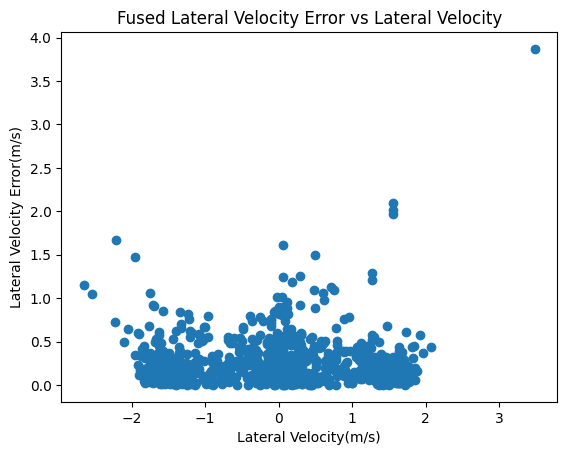

In [72]:
plt.scatter(x=df_PedestrianFusion['GT Lat_Vel'], y=df_PedestrianFusion['Error Lat_Vel'])
plt.xlabel("Lateral Velocity(m/s)")
plt.ylabel("Lateral Velocity Error(m/s)")
plt.title("Fused Lateral Velocity Error vs Lateral Velocity")

Text(0.5, 1.0, 'Fused Longitudinal Velocity Error vs Longitudinal Velocity')

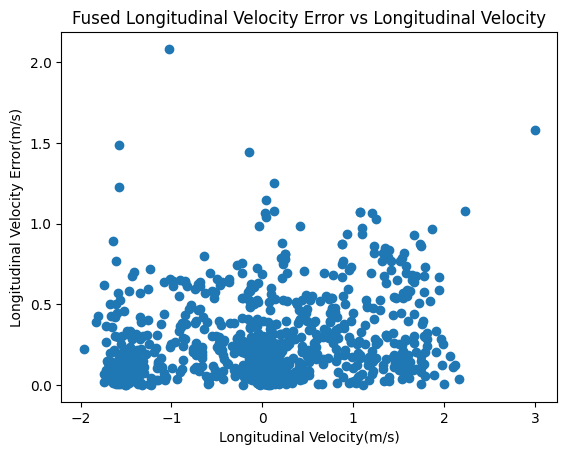

In [73]:
plt.scatter(x=df_PedestrianFusion['GT Lon_Vel'], y=df_PedestrianFusion['Error Lon_Vel'])
plt.xlabel("Longitudinal Velocity(m/s)")
plt.ylabel("Longitudinal Velocity Error(m/s)")
plt.title("Fused Longitudinal Velocity Error vs Longitudinal Velocity")

Text(0.5, 0, 'Time')

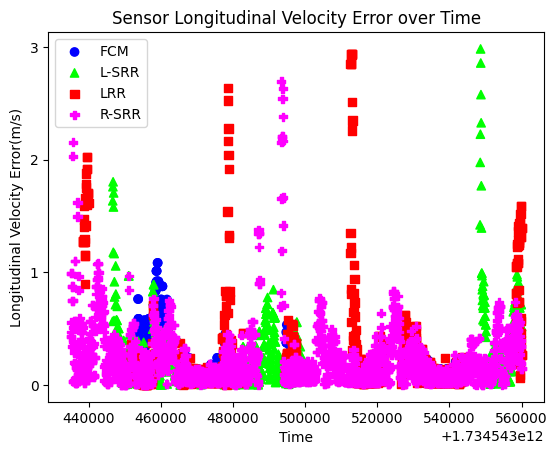

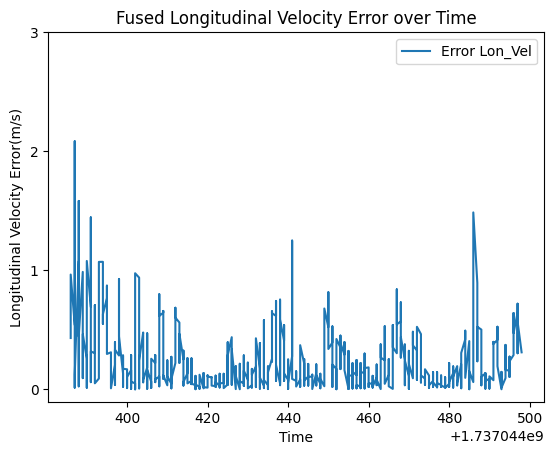

In [74]:
i = 0
for sensor, d in df_Pedestrian.groupby('sensor'):
    i+=1
    marker = markers[i]
    #if sensor == "FCM":
    #    continue
    plt.scatter(x=d['TimeStamp in ms since epoch'], y=d['lon vel error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Time")
plt.ylabel("Longitudinal Velocity Error(m/s)")
plt.title("Sensor Longitudinal Velocity Error over Time")
plt.yticks([0, 1, 2, 3])
plt.legend()

df_PedestrianFusion.plot.line(x="time", y="Error Lon_Vel")
plt.title("Fused Longitudinal Velocity Error over Time")
plt.yticks([0, 1, 2, 3])
plt.ylabel("Longitudinal Velocity Error(m/s)")
plt.xlabel("Time")

Text(0.5, 0, 'Time')

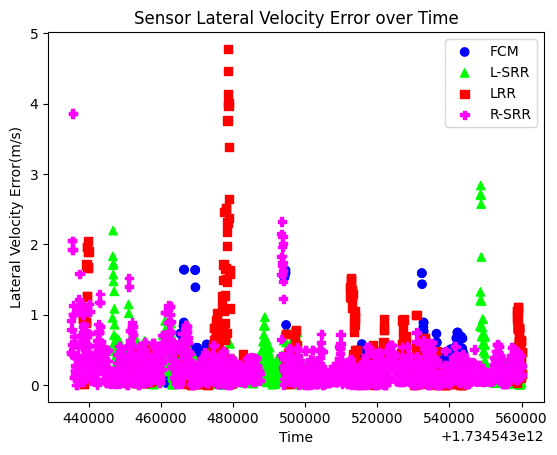

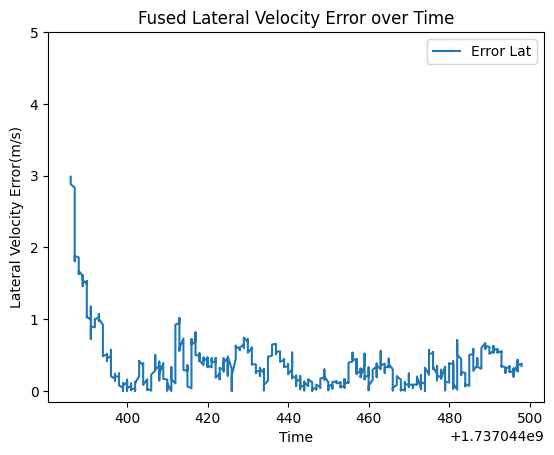

In [75]:
i = 0
for sensor, d in df_Pedestrian.groupby('sensor'):
    i+=1
    marker = markers[i]
    #if sensor == "FCM":
    #    continue
    plt.scatter(x=d['TimeStamp in ms since epoch'], y=d['lat vel error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Time")
plt.ylabel("Lateral Velocity Error(m/s)")
plt.yticks([0, 1, 2, 3, 4, 5])
plt.title("Sensor Lateral Velocity Error over Time")
plt.legend()
df_PedestrianFusion.plot.line(x="time", y="Error Lat")
plt.title("Fused Lateral Velocity Error over Time")
plt.ylabel("Lateral Velocity Error(m/s)")
plt.yticks([0, 1, 2, 3, 4, 5])
plt.xlabel("Time")


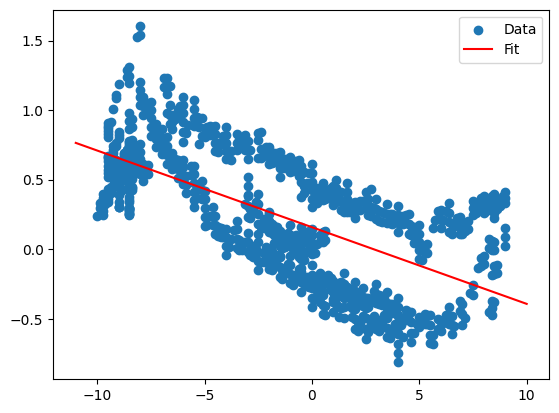

Function Parameters -0.05511392405998433 0.158242581509988
Post-Mean -7.209069341938635e-11
Post-STD 0.3360611561602104
Mean 0.2622285946956078
STD 0.45095648309232517
Correlation -0.6663943309068395


In [76]:
selected = df_Pedestrian[df_Pedestrian['sensor'] =='FCM']
col1 = 'lat offset from ego (m)'
col2 = 'lat actual error'
def func(x, a, b):
    return a * x  + b
popt, pcov = curve_fit(func, selected[col1], selected[col2])
plt.scatter(selected[col1], selected[col2], label='Data')
plt.plot(range(int(selected[col1].min())-1,int(selected[col1].max())+2), func(range(int(selected[col1].min())-1,int(selected[col1].max())+2), *popt), 'r-', label='Fit')
plt.legend()
plt.show()
print("Function Parameters",*popt)

def lon_error_func(x):
    return x[col2] - func(x[col1], *popt)
errors = []
for index, row in selected.iterrows():
    errors.append(lon_error_func(row))

print("Post-Mean",np.mean(errors))
print("Post-STD",np.std(errors))
print("Mean",selected[col2].mean())
print("STD",selected[col2].std())
print("Correlation",selected[col1].corr(selected[col2]))

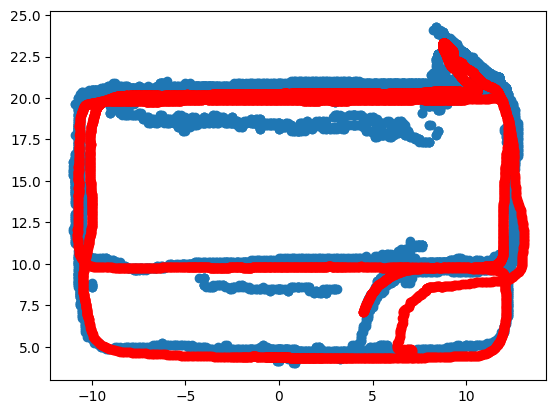

In [77]:
plt.scatter(-df_Pedestrian['lat offset from ego (m)'], df_Pedestrian['lon offset from ego (m)'])
plt.scatter(-df_Pedestrian['interpolated ground truth x in m'], df_Pedestrian['interpolated ground truth y in m'], color='Red')

In [78]:
df_PedestrianFusionCalibrated =  pd.read_csv("/home/kzb068/Documents/ProcessedData/CalibratedFusedPedestrain.csv")
df_PedestrianCalibrated =  pd.read_csv("/home/kzb068/Documents/ProcessedData/CalibratedPedestrian.csv")
df_PedestrianCalibrated["marker"] = df_PedestrianCalibrated.apply(lambda x: markers[x["sensor_id"]], axis=1)
df_PedestrianCalibrated["sensor"] = df_PedestrianCalibrated.apply(lambda x: group[x["sensor_id"]], axis=1)
df_PedestrianCalibrated["color"] = df_PedestrianCalibrated.apply(lambda x: colors[x["sensor_id"]], axis=1)

Text(0, 0.5, 'Number of Occurences')

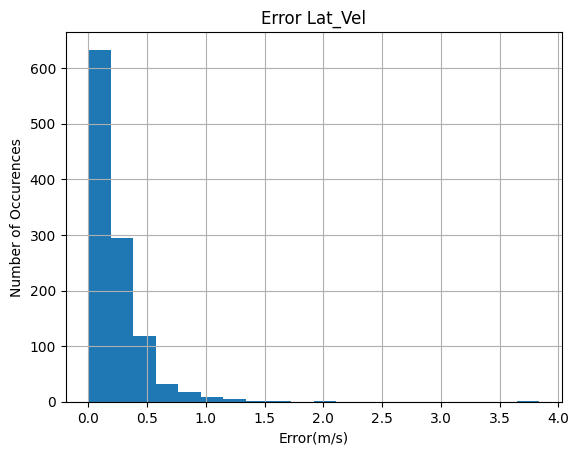

In [79]:
df_PedestrianFusionCalibrated.hist(column="Error Lat_Vel", bins=20)
plt.xlabel("Error(m/s)")
plt.ylabel("Number of Occurences")

In [80]:
print(df_PedestrianFusion['Error Lat'].mean())
print(df_PedestrianFusion['Error Lat'].std())
print(df_PedestrianFusion['Error Lon'].mean())
print(df_PedestrianFusion['Error Lon'].std())

0.37839380610412926
0.3639043816954755
0.46279999192100546
0.23379180430151883


In [81]:
print(df_PedestrianFusionCalibrated['Error Lat'].mean())
print(df_PedestrianFusionCalibrated['Error Lat'].std())
print(df_PedestrianFusionCalibrated['Error Lon'].mean())
print(df_PedestrianFusionCalibrated['Error Lon'].std())

0.31502707892376686
0.3643342025936666
0.16987806008968612
0.1621841800015318


([<matplotlib.axis.YTick at 0x7e00c14c52a0>,
 [])

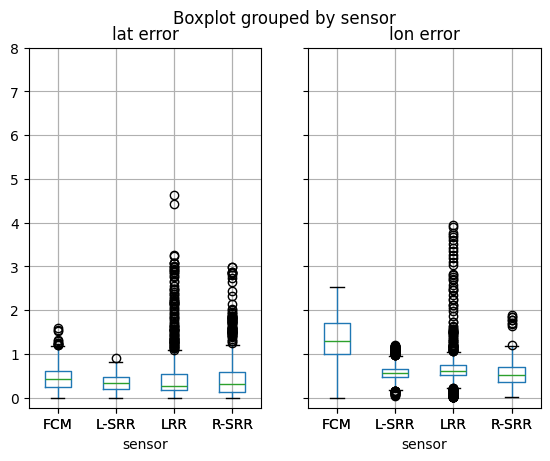

In [82]:
df_Pedestrian.boxplot(column=['lat error','lon error'], by='sensor')
plt.ylabel("Error(m)")
plt.yticks(range(0,9))

Text(0, 0.5, 'Error(m)')

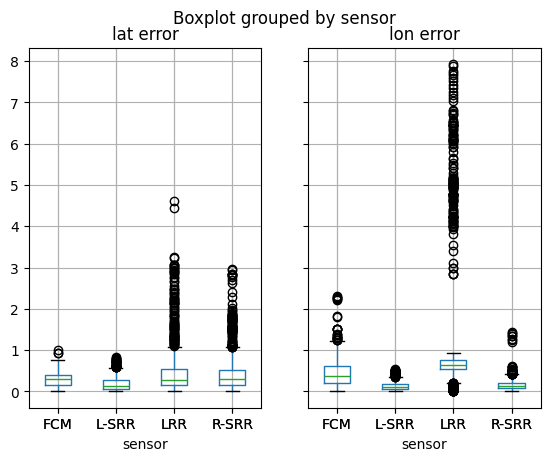

In [83]:
df_PedestrianCalibrated.boxplot(column=['lat error','lon error'], by='sensor')
plt.ylabel("Error(m)")

array([<Axes: title={'center': 'lat vel error'}, xlabel='sensor'>,
       <Axes: title={'center': 'lon vel error'}, xlabel='sensor'>],
      dtype=object)

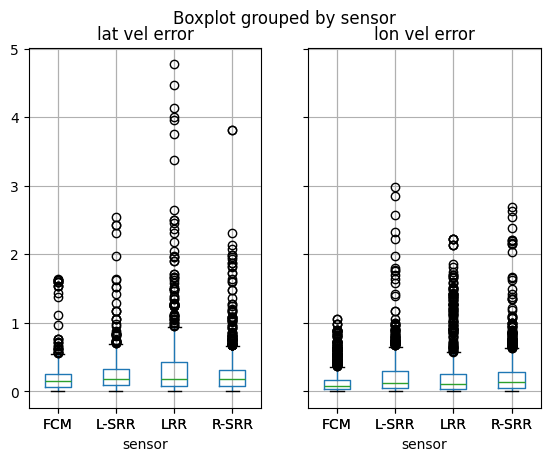

In [84]:
df_PedestrianCalibrated.boxplot(column=['lat vel error','lon vel error'], by='sensor')

Text(0, 0.5, 'Error(m)')

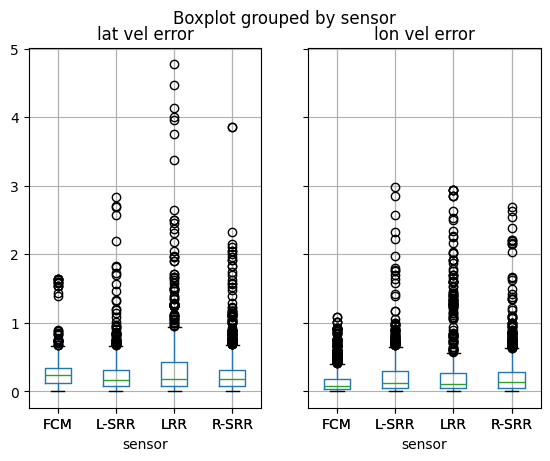

In [85]:
df_Pedestrian.boxplot(column=['lat vel error','lon vel error'], by='sensor')
plt.ylabel("Error(m)")

# Post Calibration

In [277]:
df_calibrated_RightToLeft = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc1/sc1_RightToLeft_filtered_calibrated.csv")
df_calibrated_RightToCloseTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc3/sc3_RightToCloseTurn_filtered_calibrated.csv")
# df_calibrated_LeftToCloseTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc4/sc4_LeftToCloseTurnFilteredCalibrated_Process.csv")
# df_calibrated_LeftToFarTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc5/sc5_LeftToFarTurnFilteredCalibrated_Process.csv")
# df_calibrated_FromFront = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc6/sc6_FromFrontFilteredCalibrated_Process.csv")
# df_calibrated_FromFrontLeft = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc7/sc7_FromFrontLeftFilteredCalibrated_Process.csv")
# df_calibrated = pd.concat([df_calibrated_RightToLeft, df_calibrated_RightToCloseTurn,df_calibrated_LeftToCloseTurn, df_calibrated_LeftToFarTurn, df_calibrated_FromFront, df_calibrated_FromFrontLeft])
df_calibrated = df_calibrated_RightToLeft

df_calibrated_RightToLeft_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc1/sc1_RightToLeft_fusion_calibrated.csv")
df_calibrated_RightToCloseTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc3/sc3_RightToCloseTurn_fusion_calibrated.csv")
# df_calibrated_LeftToCloseTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc4/sc4_LeftToCloseTurnFusionCalibrated.csv")
# df_calibrated_LeftToFarTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc5/sc5_LeftToFarTurnFusionCalibrated.csv")
# df_calibrated_FromFront_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc6/sc6_FromFrontFusionCalibrated.csv")
# df_calibrated_FromFrontLeft_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc7/sc7_FromFrontLeftFusionCalibrated.csv")
# df_calibrated_fused = pd.concat([df_calibrated_RightToLeft_fused, df_calibrated_RightToCloseTurn,df_calibrated_LeftToCloseTurn, df_calibrated_LeftToFarTurn_fused, df_calibrated_FromFront_fused, df_calibrated_FromFrontLeft_fused])
df_calibrated_fused = df_calibrated_RightToLeft_fused

colors = [' ', [1,0,0],[0,0,1],[0,1,0],[1,0,1]]
markers = ['.', 'o', '^', 's', 'P','p','1','*','+','x','D']
group = [' ',"LRR", "FCM", "L-SRR", "R-SRR"]

df_calibrated_subset_fused = df_calibrated_fused
df_calibrated["marker"] = df_calibrated.apply(lambda x: markers[x["sensor_id"]], axis=1)
df_calibrated["sensor"] = df_calibrated.apply(lambda x: group[x["sensor_id"]], axis=1)
df_calibrated["color"] = df_calibrated.apply(lambda x: colors[x["sensor_id"]], axis=1)
filtered_df_lat = df_calibrated[df_calibrated['lat error'] > 20]
filtered_df_lon = df_calibrated[df_calibrated['lon error'] > 30]

df_calibrated_fused

,[INFO] [1750702732.259804148] [Fusion]:,time,Obj id,Lat,Lon,Theta,Lat_Vel,Lon_Vel,Lat Cov,Lon Cov,...,GT Lon,GT Lat_Vel,GT Lon_Vel,Error Lat,Error Lon,Error Lat_Vel,Error Lon_Vel,Theta.1,Error Theta,Theta Valid
0,[INFO] [1750702735.958243022] [Fusion]:,1.750703e+09,0,-64.000000,28.381632,0.000000,0.478503,-1.525240,11.202351,2.711058,...,28.758406,0.884557,-0.847900,2.747299,0.376774,0.406054,0.677340,NaN,NaN,False
1,[INFO] [1750702736.059015650] [Fusion]:,1.750703e+09,0,-63.982548,28.434490,0.000000,0.478904,-1.569241,3.864301,1.010238,...,28.673615,0.884557,-0.847900,2.676296,0.239124,0.405653,0.721340,NaN,NaN,False
2,[INFO] [1750702736.158859650] [Fusion]:,1.750703e+09,0,-63.953987,28.497934,0.000000,0.523235,-1.533152,2.662599,0.843266,...,28.583752,1.204499,-1.039915,2.608482,0.085817,0.681264,0.493237,NaN,NaN,False
3,[INFO] [1750702736.258243679] [Fusion]:,1.750703e+09,0,-63.930164,28.479053,0.000000,0.621287,-1.568287,2.286740,0.817682,...,28.482985,1.195086,-0.939157,2.512157,0.003931,0.573799,0.629129,NaN,NaN,False
4,[INFO] [1750702736.359064428] [Fusion]:,1.750703e+09,0,-63.892914,28.397362,0.000000,0.676727,-1.677105,2.664603,1.163468,...,28.427574,1.195086,-0.939157,2.478897,0.030212,0.518359,0.737948,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,[INFO] [1750702761.758859365] [Fusion]:,1.750703e+09,0,60.054314,16.921700,1.529976,8.688624,-0.316963,0.805185,0.722668,...,16.925499,7.159683,-0.140547,2.113312,0.003799,1.528941,0.176417,1.529976,3.132748,True
259,[INFO] [1750702761.858419342] [Fusion]:,1.750703e+09,0,60.809628,16.991306,1.529976,8.576520,-0.256626,0.765547,0.688902,...,16.905748,8.296121,-0.401225,2.157726,0.085558,0.280399,0.144599,1.529976,3.135408,True
260,[INFO] [1750702761.958719952] [Fusion]:,1.750703e+09,0,61.634853,17.019459,1.529976,8.501078,-0.195876,0.759346,0.684316,...,16.867836,11.723811,-0.227215,2.221821,0.151623,3.222733,0.031339,1.529976,3.133855,True
261,[INFO] [1750702762.059211091] [Fusion]:,1.750703e+09,0,62.526882,17.074045,1.529976,8.437094,-0.088565,0.758442,0.683723,...,16.848148,8.275632,-0.160387,2.345631,0.225897,0.161462,0.071822,1.529976,3.123231,True


Text(0, 0.5, 'Error(m)')

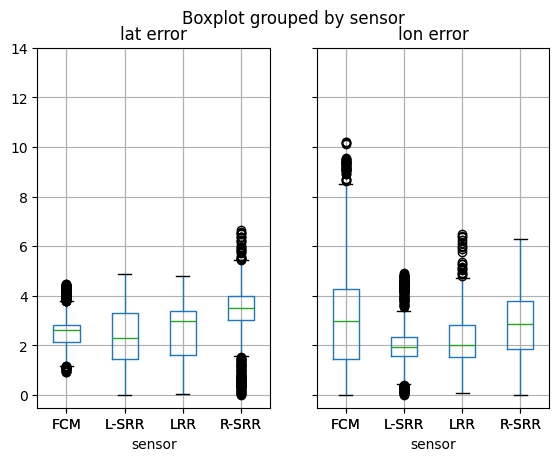

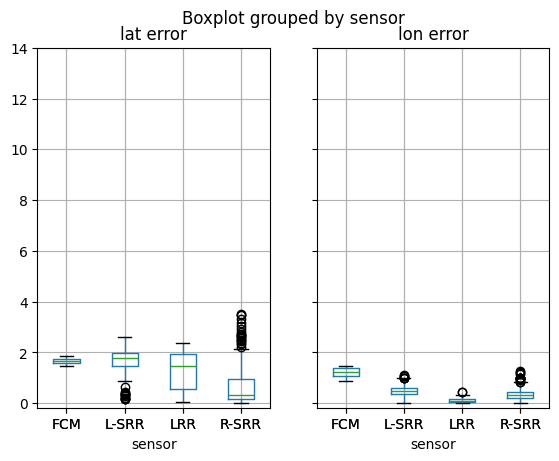

In [278]:
df.boxplot(column=['lat error','lon error'], by='sensor')
plt.yticks(range(0,16,2))
plt.ylabel("Error(m)")
df_calibrated.boxplot(column=['lat error','lon error'], by='sensor')
plt.yticks(range(0,16,2))
plt.ylabel("Error(m)")

Text(0, 0.5, 'Error(m)')

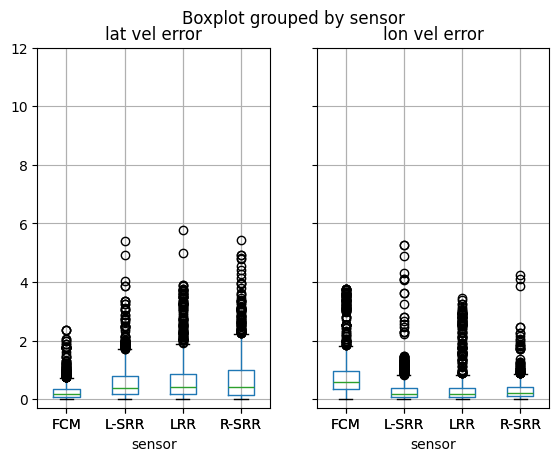

In [279]:
df.boxplot(column=['lat vel error','lon vel error'], by='sensor')
plt.yticks(range(0,14,2))
plt.ylabel("Error(m)")

Text(0, 0.5, 'Error(m)')

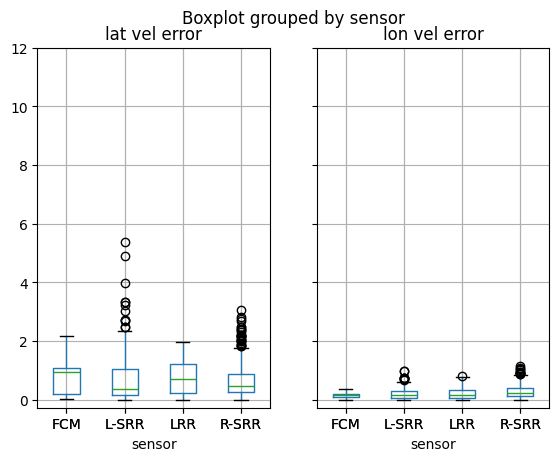

In [280]:
df_calibrated.boxplot(column=['lat vel error','lon vel error'], by='sensor')
plt.yticks(range(0,14,2))
plt.ylabel("Error(m)")

<Axes: >

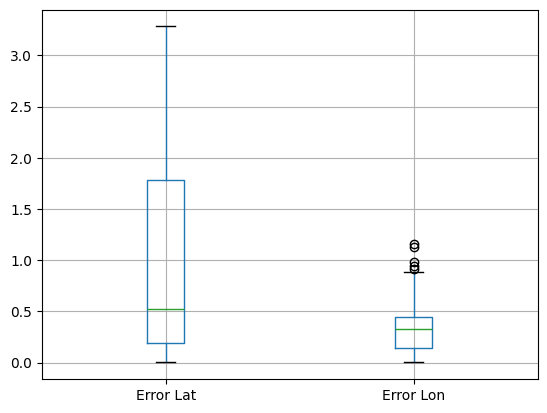

In [281]:
df_calibrated_fused.boxplot(column=['Error Lat','Error Lon'])


<Axes: >

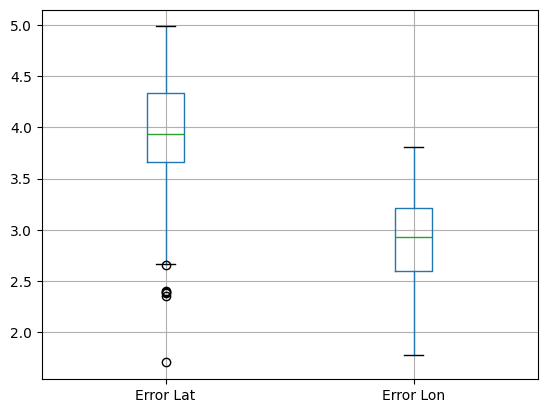

In [282]:
df_fusion.boxplot(column=['Error Lat','Error Lon'])

In [283]:
def print_stats_fusion(prefix, df_temp):
    print(f"{prefix} Lat Error Mean: {df_temp['Error Lat'].mean()}")
    print(f"{prefix} Lat Error STDEV: {df_temp['Error Lat'].std()}")
    print(f"{prefix} Lat Error Median: {df_temp['Error Lat'].median()}")
    print(f"{prefix} Lat Error Min: {df_temp['Error Lat'].min()}")
    print(f"{prefix} Lat Error Max: {df_temp['Error Lat'].max()}")

    print(f"{prefix} Lon Error Mean: {df_temp['Error Lon'].mean()}")
    print(f"{prefix} Lon Error STDEV: {df_temp['Error Lon'].std()}")
    print(f"{prefix} Lon Error Median: {df_temp['Error Lon'].median()}")
    print(f"{prefix} Lon Error Min: {df_temp['Error Lon'].min()}")
    print(f"{prefix} Lon Error Max: {df_temp['Error Lon'].max()}")

    print(f"{prefix} Lat_Vel Error Mean: {df_temp['Error Lat_Vel'].mean()}")
    print(f"{prefix} Lat_Vel Error STDEV: {df_temp['Error Lat_Vel'].std()}")
    print(f"{prefix} Lat_Vel Error Median: {df_temp['Error Lat_Vel'].median()}")
    print(f"{prefix} Lat_Vel Error Min: {df_temp['Error Lat_Vel'].min()}")
    print(f"{prefix} Lat_Vel Error Max: {df_temp['Error Lat_Vel'].max()}")

    print(f"{prefix} Lon_Vel Error Mean: {df_temp['Error Lon_Vel'].mean()}")
    print(f"{prefix} Lon_Vel Error STDEV: {df_temp['Error Lon_Vel'].std()}")
    print(f"{prefix} Lon_Vel Error Median: {df_temp['Error Lon_Vel'].median()}")
    print(f"{prefix} Lon_Vel Error Min: {df_temp['Error Lon_Vel'].min()}")
    print(f"{prefix} Lon_Vel Error Max: {df_temp['Error Lon_Vel'].max()}")

In [284]:
print_stats_fusion("Pre Calibration Absolute", df_fusion_subset)

Pre Calibration Absolute Lat Error Mean: 3.929948444444444
Pre Calibration Absolute Lat Error STDEV: 0.5554612156515268
Pre Calibration Absolute Lat Error Median: 3.935337
Pre Calibration Absolute Lat Error Min: 1.70549
Pre Calibration Absolute Lat Error Max: 4.984905
Pre Calibration Absolute Lon Error Mean: 2.889169991452991
Pre Calibration Absolute Lon Error STDEV: 0.4005767164204168
Pre Calibration Absolute Lon Error Median: 2.9322795
Pre Calibration Absolute Lon Error Min: 1.775536
Pre Calibration Absolute Lon Error Max: 3.805037
Pre Calibration Absolute Lat_Vel Error Mean: 0.6181879145299146
Pre Calibration Absolute Lat_Vel Error STDEV: 0.6255583823888632
Pre Calibration Absolute Lat_Vel Error Median: 0.42028350000000003
Pre Calibration Absolute Lat_Vel Error Min: 0.004056
Pre Calibration Absolute Lat_Vel Error Max: 3.283558
Pre Calibration Absolute Lon_Vel Error Mean: 0.2529161111111111
Pre Calibration Absolute Lon_Vel Error STDEV: 0.19276612530969917
Pre Calibration Absolute Lon

In [285]:
print_stats_fusion("Post Calibration Absolute", df_calibrated_subset_fused)

Post Calibration Absolute Lat Error Mean: 0.9789038897338403
Post Calibration Absolute Lat Error STDEV: 0.8779798219902666
Post Calibration Absolute Lat Error Median: 0.525684
Post Calibration Absolute Lat Error Min: 0.003656
Post Calibration Absolute Lat Error Max: 3.281116
Post Calibration Absolute Lon Error Mean: 0.3304083954372624
Post Calibration Absolute Lon Error STDEV: 0.22055930176250824
Post Calibration Absolute Lon Error Median: 0.325392
Post Calibration Absolute Lon Error Min: 0.001623
Post Calibration Absolute Lon Error Max: 1.154079
Post Calibration Absolute Lat_Vel Error Mean: 0.6303538174904942
Post Calibration Absolute Lat_Vel Error STDEV: 0.5810859406507103
Post Calibration Absolute Lat_Vel Error Median: 0.474665
Post Calibration Absolute Lat_Vel Error Min: 0.007226
Post Calibration Absolute Lat_Vel Error Max: 3.222733
Post Calibration Absolute Lon_Vel Error Mean: 0.2593971558935361
Post Calibration Absolute Lon_Vel Error STDEV: 0.22524084526963786
Post Calibration Ab

In [286]:
0.25518799999999997 - 0.241995

0.013192999999999983

NameError: name 'df_calibrated_LeftToFarTurn_fused' is not defined

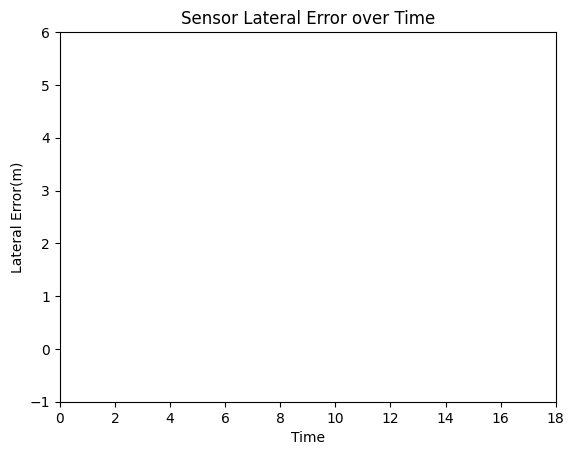

In [287]:
selected_rows = df_calibrated[df_calibrated['test_id'] =='LeftToFarTurn']
i = 0
for sensor, d in selected_rows.groupby('sensor'):
    i+=1
    marker = markers[i]
    plt.scatter(x=(d['TimeStamp in ms since epoch']-selected_rows['TimeStamp in ms since epoch'].min())/1000, y=d['lat error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Time")
plt.ylabel("Lateral Error(m)")
plt.yticks([-1, 0, 1, 2, 3, 4, 5, 6])
plt.xticks(range(0,19,2))
plt.xlim(0,18)
plt.title("Sensor Lateral Error over Time")
plt.scatter(df_calibrated_LeftToFarTurn_fused["time"]-df_calibrated_LeftToFarTurn_fused["time"].min() + 0.1, df_calibrated_LeftToFarTurn_fused["Error Lat"], label="Fused")
plt.legend()
plt.show()


NameError: name 'df_calibrated_LeftToFarTurn_fused' is not defined

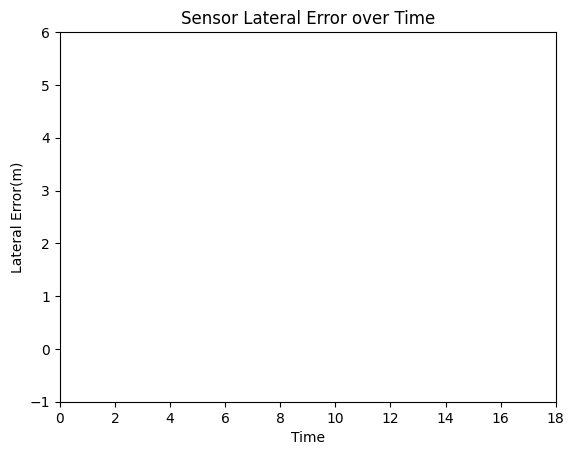

In [288]:
selected_rows = df_calibrated[df_calibrated['test_id'] =='LeftToFarTurn']
i = 0
for sensor, d in selected_rows.groupby('sensor'):
    i+=1
    marker = markers[i]
    plt.scatter(x=(d['TimeStamp in ms since epoch']-selected_rows['TimeStamp in ms since epoch'].min())/1000, y=d['lon error'], c=d['color'], marker=marker, label=sensor)
plt.xlabel("Time")
plt.ylabel("Lateral Error(m)")
plt.yticks([-1, 0, 1, 2, 3, 4, 5, 6])
plt.xticks(range(0,19,2))
plt.xlim(0,18)
plt.title("Sensor Lateral Error over Time")
plt.scatter(df_calibrated_LeftToFarTurn_fused["time"]-df_calibrated_LeftToFarTurn_fused["time"].min() + 0.1, df_calibrated_LeftToFarTurn_fused["Error Lon"], label="Fused")
plt.legend()
plt.show()

In [289]:
plt.scatter(df_calibrated_followBehind_fused["time"]-df_calibrated_followBehind_fused["time"].min() + 0.1, df_calibrated_followBehind_fused["Error Lon"], label="Post")
plt.scatter(df_followFusion["time"]-df_followFusion["time"].min() + 0.1, df_followFusion["Error Lon"], label="Pre")
plt.legend()

NameError: name 'df_calibrated_followBehind_fused' is not defined

In [290]:
plt.scatter(df_calibrated_followBehind_fused["time"]-df_calibrated_followBehind_fused["time"].min() + 0.1, df_calibrated_followBehind_fused["Error Lat"], label="Post")
plt.scatter(df_followFusion["time"]-df_followFusion["time"].min() + 0.1, df_followFusion["Error Lat"], label="Pre")
plt.legend()

NameError: name 'df_calibrated_followBehind_fused' is not defined

In [291]:
plt.scatter(df_calibrated_LeftToFarTurn_fused["time"]-df_calibrated_LeftToFarTurn_fused["time"].min() + 0.1, df_calibrated_LeftToFarTurn_fused["Error Lon"], label="Post")
plt.scatter(df_LeftToFarTurnFusion["time"]-df_LeftToFarTurnFusion["time"].min() + 0.1, df_LeftToFarTurnFusion["Error Lon"], label="Pre")
plt.legend()
plt.show()
plt.scatter(df_calibrated_LeftToFarTurn_fused["time"]-df_calibrated_LeftToFarTurn_fused["time"].min() + 0.1, df_calibrated_LeftToFarTurn_fused["Error Lat"], label="Post")
plt.scatter(df_LeftToFarTurnFusion["time"]-df_LeftToFarTurnFusion["time"].min() + 0.1, df_LeftToFarTurnFusion["Error Lat"], label="Pre")
plt.legend()
plt.show()

NameError: name 'df_calibrated_LeftToFarTurn_fused' is not defined

# Calibrated 2

In [342]:
df_calibrated_RightToLeft = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc1/sc1_RightToLeft_filtered_calibrated.csv")
df_calibrated_RightToCloseTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc3/sc3_RightToCloseTurn_filtered_calibrated.csv")
# df_calibrated_LeftToCloseTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc4/sc4_LeftToCloseTurnFilteredCalibrated_Process.csv")
# df_calibrated_LeftToFarTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc5/sc5_LeftToFarTurnFilteredCalibrated_Process.csv")
# df_calibrated_FromFront = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc6/sc6_FromFrontFilteredCalibrated_Process.csv")
# df_calibrated_FromFrontLeft = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc7/sc7_FromFrontLeftFilteredCalibrated_Process.csv")
# df_calibrated = pd.concat([df_calibrated_RightToLeft, df_calibrated_RightToCloseTurn,df_calibrated_LeftToCloseTurn, df_calibrated_LeftToFarTurn, df_calibrated_FromFront, df_calibrated_FromFrontLeft])
df_calibrated2 = df_calibrated_RightToLeft

df_calibrated_RightToLeft_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc1/sc1_RightToLeft_fusion_calibrated.csv")
df_calibrated_RightToCloseTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc3/sc3_RightToCloseTurn_fusion_calibrated.csv")
# df_calibrated_LeftToCloseTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc4/sc4_LeftToCloseTurnFusionCalibrated.csv")
# df_calibrated_LeftToFarTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc5/sc5_LeftToFarTurnFusionCalibrated.csv")
# df_calibrated_FromFront_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc6/sc6_FromFrontFusionCalibrated.csv")
# df_calibrated_FromFrontLeft_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc7/sc7_FromFrontLeftFusionCalibrated.csv")
# df_calibrated_fused = pd.concat([df_calibrated_RightToLeft_fused, df_calibrated_RightToCloseTurn,df_calibrated_LeftToCloseTurn, df_calibrated_LeftToFarTurn_fused, df_calibrated_FromFront_fused, df_calibrated_FromFrontLeft_fused])
df_calibrated2_fused = df_calibrated_RightToLeft_fused

colors = [' ', [1,0,0],[0,0,1],[0,1,0],[1,0,1]]
markers = ['.', 'o', '^', 's', 'P','p','1','*','+','x','D']
group = [' ',"LRR", "FCM", "L-SRR", "R-SRR"]

df_calibrated2["marker"] = df_calibrated2.apply(lambda x: markers[x["sensor_id"]], axis=1)
df_calibrated2["sensor"] = df_calibrated2.apply(lambda x: group[x["sensor_id"]], axis=1)
df_calibrated2["color"] = df_calibrated2.apply(lambda x: colors[x["sensor_id"]], axis=1)
filtered_df_lat = df_calibrated2[df_calibrated2['lat error'] > 20]
filtered_df_lon = df_calibrated2[df_calibrated2['lon error'] > 30]


Text(0, 0.5, 'Error(m)')

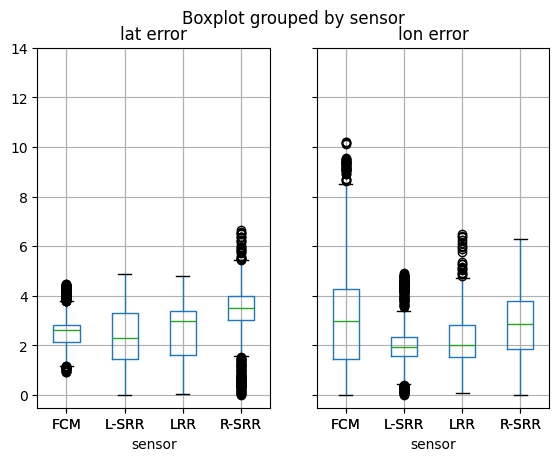

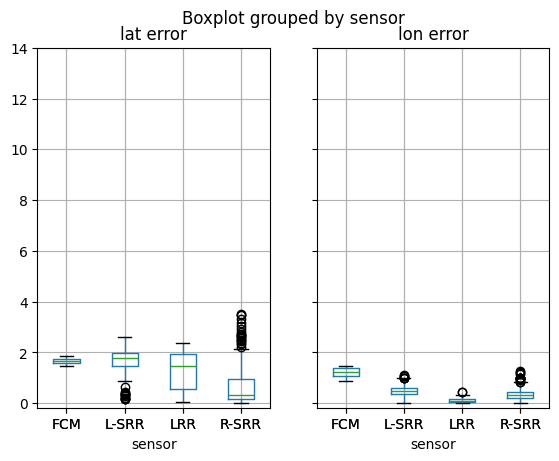

In [343]:
df_subset.boxplot(column=['lat error','lon error'], by='sensor')
plt.yticks(range(0,16,2))
plt.ylabel("Error(m)")
df_calibrated2.boxplot(column=['lat error','lon error'], by='sensor')
plt.yticks(range(0,16,2))
plt.ylabel("Error(m)")

Text(0, 0.5, 'Error(m)')

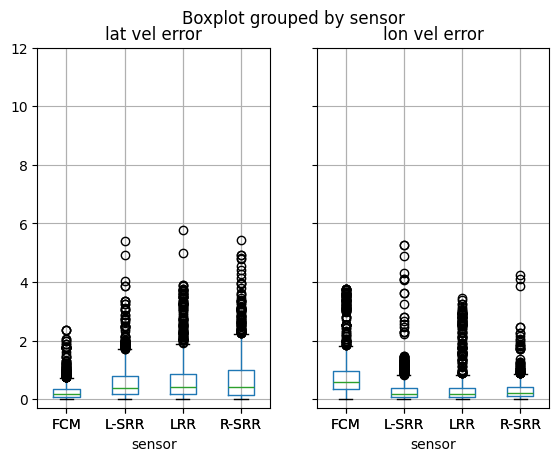

In [344]:
df_subset.boxplot(column=['lat vel error','lon vel error'], by='sensor')
plt.yticks(range(0,14,2))
plt.ylabel("Error(m)")

Text(0, 0.5, 'Error(m)')

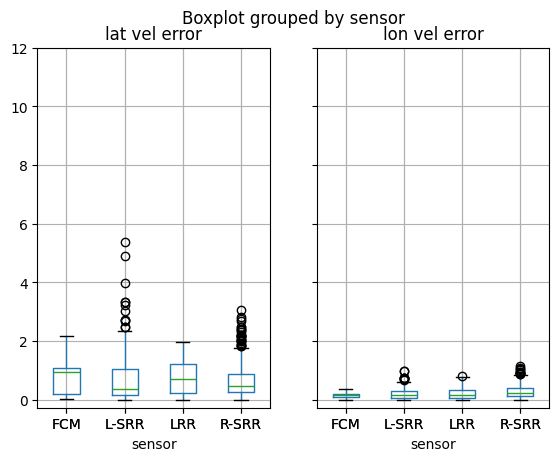

In [345]:
df_calibrated2.boxplot(column=['lat vel error','lon vel error'], by='sensor')
plt.yticks(range(0,14,2))
plt.ylabel("Error(m)")

In [346]:
selected_rows = df_calibrated2[df_calibrated2['sensor'] =='R-SRR']
col = 'lat error'
print("Cal")
print(selected_rows[col].mean())
print(selected_rows[col].median())
print(selected_rows[col].std())
selected_rows = df_subset[df_subset['sensor'] =='R-SRR']
print("Raw")
print(selected_rows[col].mean())
print(selected_rows[col].median())
print(selected_rows[col].std())

Cal
0.6505449431984843
0.345218801708846
0.7067953529169991
Raw
3.3585707130736813
3.509010720819175
1.1177558007858976


/tmp/ipykernel_2549759/2283564976.py:6: RuntimeWarning: divide by zero encountered in log
  return a * np.log(x) + b


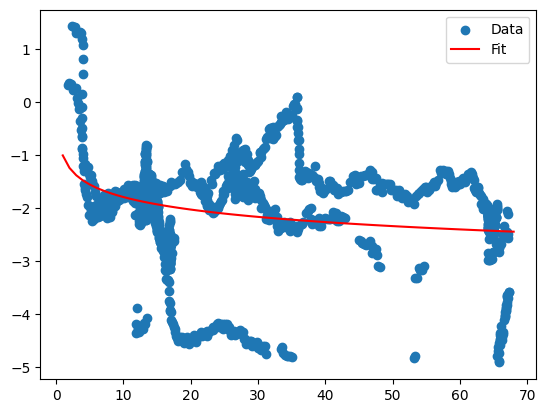

-0.3409485272397145 -1.0009831659742028
6.32032454324481e-16
0.9345095704752615
-2.0499637683019896
0.9659009891999046
-0.18989050128421134


In [347]:
selected = df_subset[df_subset['sensor'] =='L-SRR']
col1 = 'lon offset from ego (m)'
#col1 = 'lat_vel w.r.t ego (m/s)'
col2 = 'lon actual error'
def func(x, a, b):
    return a * np.log(x) + b
popt, pcov = curve_fit(func, selected[col1], selected[col2])
plt.scatter(selected[col1], selected[col2], label='Data')
plt.plot(range(int(selected[col1].min())-1,int(selected[col1].max())+2), func(range(int(selected[col1].min())-1,int(selected[col1].max())+2), *popt), 'r-', label='Fit')
plt.legend()
plt.show()
print(*popt)

def lon_error_func(x):
    return x[col2] - func(x[col1], *popt)
errors = []
for index, row in selected.iterrows():
    errors.append(lon_error_func(row))

print(np.mean(errors))
print(np.std(errors))
print(selected[col2].mean())
print(selected[col2].std())
print(selected[col1].corr(selected[col2]))

In [348]:
print_stats_fusion("Pre Calibration Absolute", df_fusion_subset)

Pre Calibration Absolute Lat Error Mean: 3.929948444444444
Pre Calibration Absolute Lat Error STDEV: 0.5554612156515268
Pre Calibration Absolute Lat Error Median: 3.935337
Pre Calibration Absolute Lat Error Min: 1.70549
Pre Calibration Absolute Lat Error Max: 4.984905
Pre Calibration Absolute Lon Error Mean: 2.889169991452991
Pre Calibration Absolute Lon Error STDEV: 0.4005767164204168
Pre Calibration Absolute Lon Error Median: 2.9322795
Pre Calibration Absolute Lon Error Min: 1.775536
Pre Calibration Absolute Lon Error Max: 3.805037
Pre Calibration Absolute Lat_Vel Error Mean: 0.6181879145299146
Pre Calibration Absolute Lat_Vel Error STDEV: 0.6255583823888632
Pre Calibration Absolute Lat_Vel Error Median: 0.42028350000000003
Pre Calibration Absolute Lat_Vel Error Min: 0.004056
Pre Calibration Absolute Lat_Vel Error Max: 3.283558
Pre Calibration Absolute Lon_Vel Error Mean: 0.2529161111111111
Pre Calibration Absolute Lon_Vel Error STDEV: 0.19276612530969917
Pre Calibration Absolute Lon

In [349]:
print_stats_fusion("Post Calibration Absolute", df_calibrated2_fused)

Post Calibration Absolute Lat Error Mean: 0.9789038897338403
Post Calibration Absolute Lat Error STDEV: 0.8779798219902666
Post Calibration Absolute Lat Error Median: 0.525684
Post Calibration Absolute Lat Error Min: 0.003656
Post Calibration Absolute Lat Error Max: 3.281116
Post Calibration Absolute Lon Error Mean: 0.3304083954372624
Post Calibration Absolute Lon Error STDEV: 0.22055930176250824
Post Calibration Absolute Lon Error Median: 0.325392
Post Calibration Absolute Lon Error Min: 0.001623
Post Calibration Absolute Lon Error Max: 1.154079
Post Calibration Absolute Lat_Vel Error Mean: 0.6303538174904942
Post Calibration Absolute Lat_Vel Error STDEV: 0.5810859406507103
Post Calibration Absolute Lat_Vel Error Median: 0.474665
Post Calibration Absolute Lat_Vel Error Min: 0.007226
Post Calibration Absolute Lat_Vel Error Max: 3.222733
Post Calibration Absolute Lon_Vel Error Mean: 0.2593971558935361
Post Calibration Absolute Lon_Vel Error STDEV: 0.22524084526963786
Post Calibration Ab

# Calibrated 3

In [350]:
df_calibrated_RightToLeft = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc1/sc1_RightToLeft_filtered_calibrated.csv")
df_calibrated_RightToCloseTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc3/sc3_RightToCloseTurn_filtered_calibrated.csv")
# df_calibrated_LeftToCloseTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc4/sc4_LeftToCloseTurnFilteredCalibrated_Process.csv")
# df_calibrated_LeftToFarTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc5/sc5_LeftToFarTurnFilteredCalibrated_Process.csv")
# df_calibrated_FromFront = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc6/sc6_FromFrontFilteredCalibrated_Process.csv")
# df_calibrated_FromFrontLeft = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc7/sc7_FromFrontLeftFilteredCalibrated_Process.csv")
# df_calibrated = pd.concat([df_calibrated_RightToLeft, df_calibrated_RightToCloseTurn,df_calibrated_LeftToCloseTurn, df_calibrated_LeftToFarTurn, df_calibrated_FromFront, df_calibrated_FromFrontLeft])
df_calibrated2 = df_calibrated_RightToLeft

df_calibrated_RightToLeft_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc1/sc1_RightToLeft_fusion_calibrated.csv")
df_calibrated_RightToCloseTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc3/sc3_RightToCloseTurn_fusion_calibrated.csv")
# df_calibrated_LeftToCloseTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc4/sc4_LeftToCloseTurnFusionCalibrated.csv")
# df_calibrated_LeftToFarTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc5/sc5_LeftToFarTurnFusionCalibrated.csv")
# df_calibrated_FromFront_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc6/sc6_FromFrontFusionCalibrated.csv")
# df_calibrated_FromFrontLeft_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc7/sc7_FromFrontLeftFusionCalibrated.csv")
# df_calibrated_fused = pd.concat([df_calibrated_RightToLeft_fused, df_calibrated_RightToCloseTurn,df_calibrated_LeftToCloseTurn, df_calibrated_LeftToFarTurn_fused, df_calibrated_FromFront_fused, df_calibrated_FromFrontLeft_fused])
df_calibrated2_fused = df_calibrated_RightToLeft_fused
colors = [' ', [1,0,0],[0,0,1],[0,1,0],[1,0,1]]
markers = ['.', 'o', '^', 's', 'P','p','1','*','+','x','D']
group = [' ',"LRR", "FCM", "L-SRR", "R-SRR"]


df_calibrated3["marker"] = df_calibrated3.apply(lambda x: markers[x["sensor_id"]], axis=1)
df_calibrated3["sensor"] = df_calibrated3.apply(lambda x: group[x["sensor_id"]], axis=1)
df_calibrated3["color"] = df_calibrated3.apply(lambda x: colors[x["sensor_id"]], axis=1)
filtered_df_lat = df_calibrated3[df_calibrated3['lat error'] > 20]
filtered_df_lon = df_calibrated3[df_calibrated3['lon error'] > 30]

df_calibrated3['lat actual error'] = df_calibrated3['lat offset from ego (m)'] - df_calibrated3['interpolated ground truth x in m']
df_calibrated3['lon actual error'] = df_calibrated3['lon offset from ego (m)'] - df_calibrated3['interpolated ground truth y in m']
df_calibrated3['lat_vel actual error'] = df_calibrated3['lat_vel w.r.t ego (m/s)'] - df_calibrated3['interpolated x velocity in m/s']
df_calibrated3['lon_vel actual error'] = df_calibrated3['lon_vel w.r.t. ego (m/s)'] - df_calibrated3['interpolated y velocity in m/s']


Text(0, 0.5, 'Error(m)')

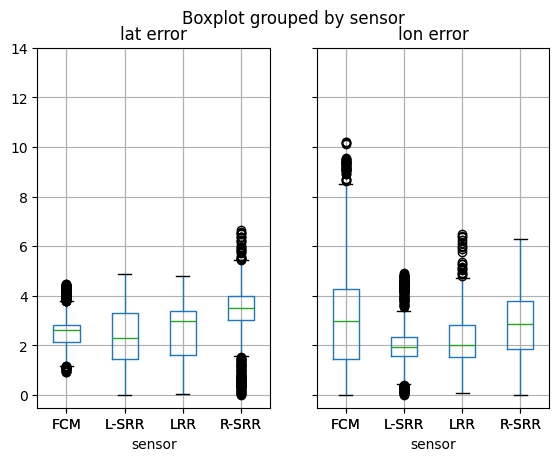

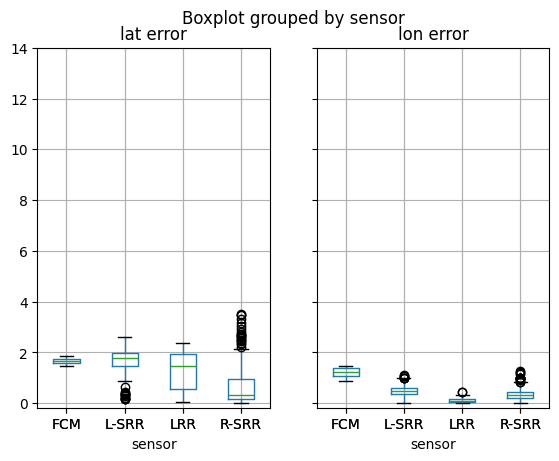

In [351]:
df_subset.boxplot(column=['lat error','lon error'], by='sensor')
plt.yticks(range(0,16,2))
plt.ylabel("Error(m)")
df_calibrated3.boxplot(column=['lat error','lon error'], by='sensor')
plt.yticks(range(0,16,2))
plt.ylabel("Error(m)")

Text(0, 0.5, 'Error(m)')

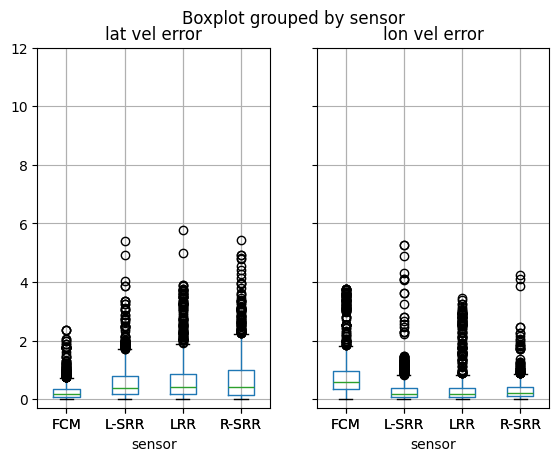

In [352]:
df_subset.boxplot(column=['lat vel error','lon vel error'], by='sensor')
plt.yticks(range(0,14,2))
plt.ylabel("Error(m)")

Text(0, 0.5, 'Error(m/s)')

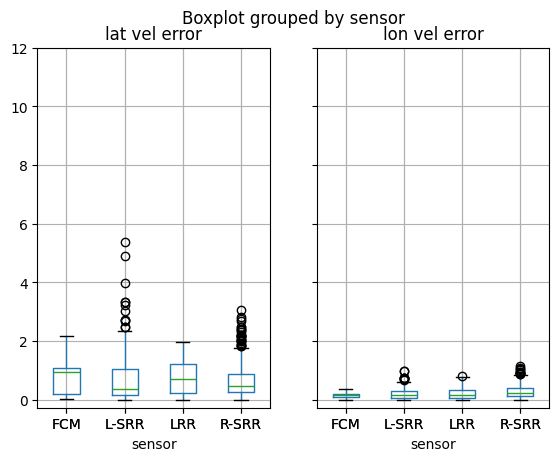

In [353]:
df_calibrated3.boxplot(column=['lat vel error','lon vel error'], by='sensor')
plt.yticks(range(0,14,2))
plt.ylabel("Error(m/s)")

In [354]:
selected_rows = df_calibrated3[df_calibrated3['sensor'] =='R-SRR']
col = 'lat error'
print("Cal")
print(selected_rows[col].mean())
print(selected_rows[col].median())
print(selected_rows[col].std())
selected_rows = df_subset[df_subset['sensor'] =='R-SRR']
print("Raw")
print(selected_rows[col].mean())
print(selected_rows[col].median())
print(selected_rows[col].std())

Cal
0.6505449431984843
0.345218801708846
0.7067953529169991
Raw
3.3585707130736813
3.509010720819175
1.1177558007858976


In [355]:
print_stats_fusion("Post Calibration Absolute", df_calibrated3_fused)

Post Calibration Absolute Lat Error Mean: 0.9789038897338403
Post Calibration Absolute Lat Error STDEV: 0.8779798219902666
Post Calibration Absolute Lat Error Median: 0.525684
Post Calibration Absolute Lat Error Min: 0.003656
Post Calibration Absolute Lat Error Max: 3.281116
Post Calibration Absolute Lon Error Mean: 0.3304083954372624
Post Calibration Absolute Lon Error STDEV: 0.22055930176250824
Post Calibration Absolute Lon Error Median: 0.325392
Post Calibration Absolute Lon Error Min: 0.001623
Post Calibration Absolute Lon Error Max: 1.154079
Post Calibration Absolute Lat_Vel Error Mean: 0.6303538174904942
Post Calibration Absolute Lat_Vel Error STDEV: 0.5810859406507103
Post Calibration Absolute Lat_Vel Error Median: 0.474665
Post Calibration Absolute Lat_Vel Error Min: 0.007226
Post Calibration Absolute Lat_Vel Error Max: 3.222733
Post Calibration Absolute Lon_Vel Error Mean: 0.2593971558935361
Post Calibration Absolute Lon_Vel Error STDEV: 0.22524084526963786
Post Calibration Ab

In [356]:
print_stats_fusion("Pre Calibration Absolute", df_fusion_subset)

Pre Calibration Absolute Lat Error Mean: 3.929948444444444
Pre Calibration Absolute Lat Error STDEV: 0.5554612156515268
Pre Calibration Absolute Lat Error Median: 3.935337
Pre Calibration Absolute Lat Error Min: 1.70549
Pre Calibration Absolute Lat Error Max: 4.984905
Pre Calibration Absolute Lon Error Mean: 2.889169991452991
Pre Calibration Absolute Lon Error STDEV: 0.4005767164204168
Pre Calibration Absolute Lon Error Median: 2.9322795
Pre Calibration Absolute Lon Error Min: 1.775536
Pre Calibration Absolute Lon Error Max: 3.805037
Pre Calibration Absolute Lat_Vel Error Mean: 0.6181879145299146
Pre Calibration Absolute Lat_Vel Error STDEV: 0.6255583823888632
Pre Calibration Absolute Lat_Vel Error Median: 0.42028350000000003
Pre Calibration Absolute Lat_Vel Error Min: 0.004056
Pre Calibration Absolute Lat_Vel Error Max: 3.283558
Pre Calibration Absolute Lon_Vel Error Mean: 0.2529161111111111
Pre Calibration Absolute Lon_Vel Error STDEV: 0.19276612530969917
Pre Calibration Absolute Lon

In [357]:
df_LRR = df_subset[df_subset['sensor'] =='LRR']
df_LSRR = df_subset[df_subset['sensor'] =='L-SRR']
df_RSRR = df_subset[df_subset['sensor'] =='R-SRR']
df_FCM = df_subset[df_subset['sensor'] =='FCM']


df_LRR_cal3 = df_calibrated3[df_calibrated3['sensor'] == 'LRR']
df_LSRR_cal3 = df_calibrated3[df_calibrated3['sensor'] == 'L-SRR']
df_RSRR_cal3 = df_calibrated3[df_calibrated3['sensor'] == 'R-SRR']
df_FCM_cal3 = df_calibrated3[df_calibrated3['sensor'] == 'FCM']

In [358]:
print_stats("Raw", df_LSRR)
print()
print_stats("Cal3", df_LSRR_cal3)

Raw Lat Actual Error Mean: 2.3014358422303145
Raw Lat Actual Error STDEV: 1.2578432504386736
Raw Lat Actual Error Median: 2.2862434255200004
Raw Lat Actual Error Min: -2.3163171435364003
Raw Lat Actual Error Max: 4.899178877005099
Raw Lon Actual Error Mean: -2.0499637683019896
Raw Lat Actual Error STDEV: 0.9659009891999046
Raw Lon Actual Error Median: -1.9500181616450014
Raw Lon Actual Error Min: -4.9071464184251
Raw Lon Actual Error Max: 1.4308927185505649
Raw Lat_Vel Actual Error Mean: 0.03062625964147117
Raw Lat_Vel Actual Error STDEV: 0.8450576530193229
Raw Lat_Vel Actual Error Median: 0.06924213159833004
Raw Lat_Vel Actual Error Min: -5.4158940878289
Raw Lat_Vel Actual Error Max: 3.87370374905694
Raw Lon_Vel Actual Error Mean: -0.07676799858670916
Raw Lon_Vel Actual Error STDEV: 0.579667585031832
Raw Lon_Vel Actual Error Median: -0.03320872244202988
Raw Lon_Vel Actual Error Min: -5.276978103142291
Raw Lon_Vel Actual Error Max: 3.6110934550018703

Cal3 Lat Actual Error Mean: -1.657

In [359]:
print(df_LSRR_cal3['lat error'].mean())

1.6647148076382512


In [360]:
temp = df_LRR['lat offset from ego (m)'] - 0.32363373398958334

In [361]:
print((temp - df_LRR['interpolated ground truth x in m']).mean())

2.0954201352561537


In [362]:
temp= df_LRR[df_LRR['object_type'] == "True"]

In [363]:
temp

,TimeStamp in ms since epoch,sensor_id,track_id,track_status,confidence,object_type,lat offset from ego (m),lon offset from ego (m),lat_vel w.r.t ego (m/s),lon_vel w.r.t. ego (m/s),...,test_id,marker,sensor,color,lat actual error,lon actual error,lat_vel actual error,lon_vel actual error,lat_stdevs,lon_stdevs


In [364]:
temp = df_calibrated3[df_calibrated3['theta w.r.t. ego'].notna()]
temp_heading_error = temp['theta w.r.t. ego'] - temp['interpolated heading in radians']
temp_heading_error.std()

0.02683736802594978

In [365]:
df_calibrated3_w_follow

NameError: name 'df_calibrated3_w_follow' is not defined

KeyError: 'sensor'

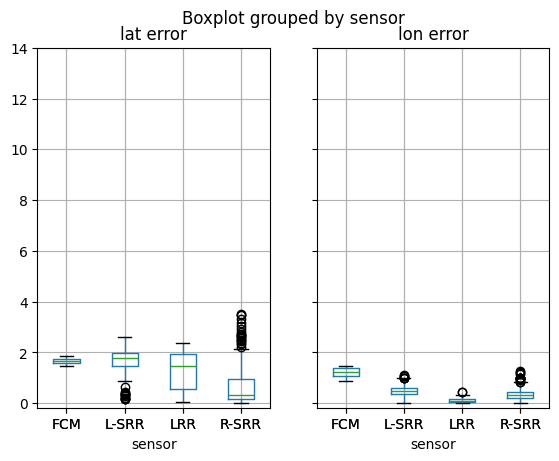

In [366]:
df_calibrated3.boxplot(column=['lat error','lon error'], by='sensor')
plt.yticks(range(0,16,2))
plt.ylabel("Error(m)")
df_calibrated2.boxplot(column=['lat error','lon error'], by='sensor')
plt.yticks(range(0,16,2))
plt.ylabel("Error(m)")

# Testing Calibration Issue

In [367]:
test1 = df_subset[df_subset['object_type'] == False]
test1

,TimeStamp in ms since epoch,sensor_id,track_id,track_status,confidence,object_type,lat offset from ego (m),lon offset from ego (m),lat_vel w.r.t ego (m/s),lon_vel w.r.t. ego (m/s),...,test_id,marker,sensor,color,lat actual error,lon actual error,lat_vel actual error,lon_vel actual error,lat_stdevs,lon_stdevs
0,1749564567273,4,29,3,2,False,64.000,25.375,0.625,-1.500,...,RightToLeft,P,R-SRR,"[1, 0, 1]",-2.791530,-3.425800,-0.259557,-0.652100,2,1
1,1749564567323,4,29,3,2,False,64.000,25.500,0.750,-1.500,...,RightToLeft,P,R-SRR,"[1, 0, 1]",-2.747302,-3.258405,-0.134557,-0.652100,2,1
2,1749564567374,4,29,3,2,False,64.000,25.625,0.750,-1.500,...,RightToLeft,P,R-SRR,"[1, 0, 1]",-2.702190,-3.090162,-0.134557,-0.652100,2,1
3,1749564567423,4,29,3,2,False,64.000,25.625,0.750,-1.625,...,RightToLeft,P,R-SRR,"[1, 0, 1]",-2.658847,-3.048615,-0.134557,-0.777100,2,1
4,1749564567474,4,29,3,2,False,64.000,25.750,0.750,-1.500,...,RightToLeft,P,R-SRR,"[1, 0, 1]",-2.613734,-2.880372,-0.134557,-0.652100,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1222,1749564948936,4,25,3,2,False,8.875,15.875,-7.875,-3.125,...,FromFrontLeft,P,R-SRR,"[1, 0, 1]",1.140387,-1.851141,-3.128129,-2.017561,0,0
1223,1749564948946,1,57,3,3,False,10.375,17.375,-7.125,-3.750,...,FromFrontLeft,o,LRR,"[1, 0, 0]",2.592918,-0.340067,-2.378129,-2.642561,3,0
1224,1749564948987,4,25,3,2,False,9.125,15.750,-8.000,-3.125,...,FromFrontLeft,P,R-SRR,"[1, 0, 1]",1.151589,-1.924521,-3.359356,-2.174289,0,0
1225,1749564949006,1,57,3,3,False,10.625,17.000,-7.125,-3.750,...,FromFrontLeft,o,LRR,"[1, 0, 0]",2.563417,-0.656457,-2.484356,-2.799289,3,0


In [368]:
test2 = df_calibrated3[df_calibrated3['object_type'] == False]
test2

,TimeStamp in ms since epoch,sensor_id,track_id,track_status,confidence,object_type,lat offset from ego (m),lon offset from ego (m),lat_vel w.r.t ego (m/s),lon_vel w.r.t. ego (m/s),...,int ego longitude,int ego heading,test_id,marker,sensor,color,lat actual error,lon actual error,lat_vel actual error,lon_vel actual error
0,1749564567273,4,29,3,2,False,-64.000000,28.256632,0.353503,-1.525240,...,-83.043773,4.741501,RightToLeft,P,R-SRR,"[1, 0, 1]",2.791530,-0.544168,-0.531054,-0.677340
1,1749564567323,4,29,3,2,False,-64.000000,28.381632,0.478503,-1.525240,...,-83.043773,4.741501,RightToLeft,P,R-SRR,"[1, 0, 1]",2.747302,-0.376773,-0.406054,-0.677340
2,1749564567374,4,29,3,2,False,-64.000000,28.506632,0.478503,-1.525240,...,-83.043773,4.741501,RightToLeft,P,R-SRR,"[1, 0, 1]",2.702190,-0.208530,-0.406054,-0.677340
3,1749564567423,4,29,3,2,False,-64.000000,28.506632,0.478503,-1.645454,...,-83.043773,4.741501,RightToLeft,P,R-SRR,"[1, 0, 1]",2.658847,-0.166983,-0.406054,-0.797554
4,1749564567474,4,29,3,2,False,-64.000000,28.631632,0.478503,-1.525240,...,-83.043773,4.741501,RightToLeft,P,R-SRR,"[1, 0, 1]",2.613734,0.001260,-0.406054,-0.677340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,1749564592269,3,44,3,2,False,61.426436,17.049964,8.530626,-0.173232,...,-83.043773,4.741501,RightToLeft,s,L-SRR,"[0, 1, 0]",-2.046979,0.168690,0.234506,0.227993
660,1749564592309,3,44,3,2,False,61.801436,17.049964,8.405626,-0.173232,...,-83.043773,4.741501,RightToLeft,s,L-SRR,"[0, 1, 0]",-2.055240,0.182129,-3.318185,0.053983
661,1749564592358,3,44,3,2,False,62.301436,17.049964,8.405626,-0.173232,...,-83.043773,4.741501,RightToLeft,s,L-SRR,"[0, 1, 0]",-2.129706,0.193262,-3.318185,0.053983
662,1749564592408,3,44,3,2,False,62.801436,17.174964,8.405626,0.076768,...,-83.043773,4.741501,RightToLeft,s,L-SRR,"[0, 1, 0]",-2.071073,0.326816,0.129995,0.237155


Text(0, 0.5, 'Error(m)')

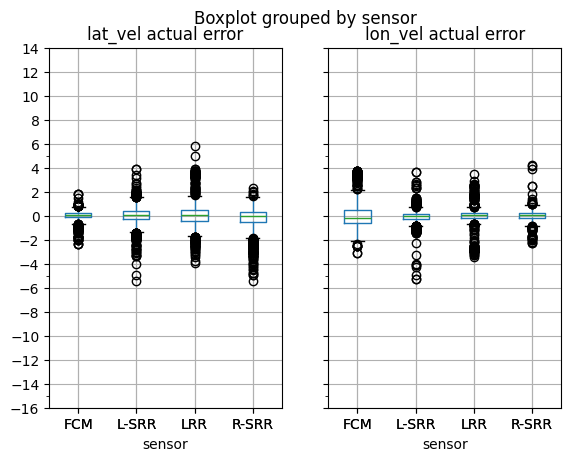

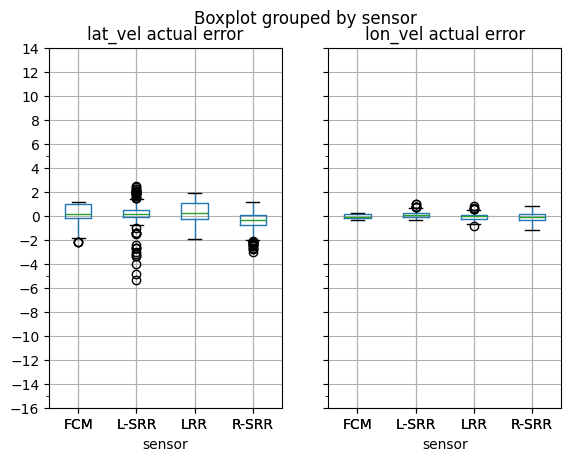

In [369]:
test1.boxplot(column=['lat_vel actual error','lon_vel actual error'], by='sensor')
plt.yticks(range(-16,16,2))
plt.ylabel("Error(m)")
test2.boxplot(column=['lat_vel actual error','lon_vel actual error'], by='sensor')
plt.yticks(range(-16,16,2))
plt.ylabel("Error(m)")

In [370]:
df_LRR = test1[test1['sensor'] =='LRR']
df_LSRR = test1[test1['sensor'] =='L-SRR']
df_RSRR = test1[test1['sensor'] =='R-SRR']
df_FCM = test1[test1['sensor'] =='FCM']


df_LRR_cal3 = test2[test2['sensor'] == 'LRR']
df_LSRR_cal3 = test2[test2['sensor'] == 'L-SRR']
df_RSRR_cal3 = test2[test2['sensor'] == 'R-SRR']
df_FCM_cal3 = test2[test2['sensor'] == 'FCM']

In [371]:
print_stats("Raw",df_LRR)
print()
print_stats("Cal3",df_LRR_cal3)

Raw Lat Actual Error Mean: 2.419053869245737
Raw Lat Actual Error STDEV: 1.4507724901249546
Raw Lat Actual Error Median: 2.917955257881308
Raw Lat Actual Error Min: -3.89903843273986
Raw Lat Actual Error Max: 4.801308093543399
Raw Lon Actual Error Mean: -2.33699173973884
Raw Lat Actual Error STDEV: 1.0334936547837936
Raw Lon Actual Error Median: -2.0342527037545004
Raw Lon Actual Error Min: -6.501603045202302
Raw Lon Actual Error Max: 0.07942081193819917
Raw Lat_Vel Actual Error Mean: 0.09208924903867813
Raw Lat_Vel Actual Error STDEV: 1.0854550774863672
Raw Lat_Vel Actual Error Median: 0.03296742939389902
Raw Lat_Vel Actual Error Min: -3.90685006212133
Raw Lat_Vel Actual Error Max: 5.77183701988562
Raw Lon_Vel Actual Error Mean: -0.02970084641753572
Raw Lon_Vel Actual Error STDEV: 0.79430056505056
Raw Lon_Vel Actual Error Median: 0.024593329748820114
Raw Lon_Vel Actual Error Min: -3.39973954885114
Raw Lon_Vel Actual Error Max: 3.44670666456088

Cal3 Lat Actual Error Mean: -0.227026076

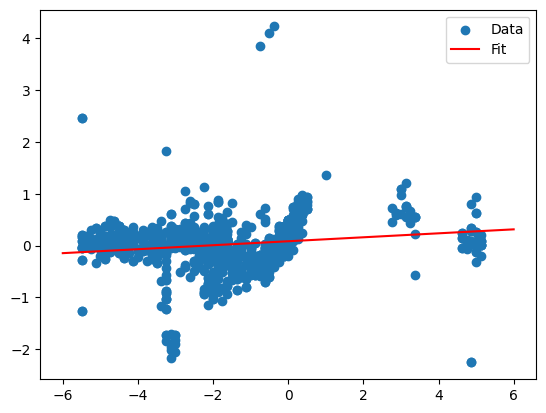

0.038288190138033196 0.08267236285070168
-9.609199448371838e-13
0.47487624926323413
0.028666963592545256
0.48150865881985333
0.1630066281900743


In [372]:
selected = test1[test1['sensor'] =='R-SRR']
#col1 = 'lon offset from ego (m)'
col1 = 'lon_vel w.r.t. ego (m/s)'
col2 = 'lon_vel actual error'
def func(x, a, b):
    return a * (x) + b
popt, pcov = curve_fit(func, selected[col1], selected[col2])
plt.scatter(selected[col1], selected[col2], label='Data')
plt.plot(range(int(selected[col1].min())-1,int(selected[col1].max())+2), func(range(int(selected[col1].min())-1,int(selected[col1].max())+2), *popt), 'r-', label='Fit')
plt.legend()
plt.show()
print(*popt)

def lon_error_func(x):
    return x[col2] - func(x[col1], *popt)
errors = []
for index, row in selected.iterrows():
    errors.append(lon_error_func(row))

print(np.mean(errors))
print(np.std(errors))
print(selected[col2].mean())
print(selected[col2].std())
print(selected[col1].corr(selected[col2]))

# Calibrated 4

In [373]:
df_calibrated_RightToLeft = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc1/sc1_RightToLeft_filtered_calibrated.csv")
df_calibrated_RightToCloseTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc3/sc3_RightToCloseTurn_filtered_calibrated.csv")
# df_calibrated_LeftToCloseTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc4/sc4_LeftToCloseTurnFilteredCalibrated_Process.csv")
# df_calibrated_LeftToFarTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc5/sc5_LeftToFarTurnFilteredCalibrated_Process.csv")
# df_calibrated_FromFront = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc6/sc6_FromFrontFilteredCalibrated_Process.csv")
# df_calibrated_FromFrontLeft = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc7/sc7_FromFrontLeftFilteredCalibrated_Process.csv")
# df_calibrated = pd.concat([df_calibrated_RightToLeft, df_calibrated_RightToCloseTurn,df_calibrated_LeftToCloseTurn, df_calibrated_LeftToFarTurn, df_calibrated_FromFront, df_calibrated_FromFrontLeft])
df_calibrated4 = df_calibrated_RightToLeft

df_calibrated_RightToLeft_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc1/sc1_RightToLeft_fusion_calibrated.csv")
df_calibrated_RightToCloseTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc3/sc3_RightToCloseTurn_fusion_calibrated.csv")
# df_calibrated_LeftToCloseTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc4/sc4_LeftToCloseTurnFusionCalibrated.csv")
# df_calibrated_LeftToFarTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc5/sc5_LeftToFarTurnFusionCalibrated.csv")
# df_calibrated_FromFront_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc6/sc6_FromFrontFusionCalibrated.csv")
# df_calibrated_FromFrontLeft_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc7/sc7_FromFrontLeftFusionCalibrated.csv")
# df_calibrated_fused = pd.concat([df_calibrated_RightToLeft_fused, df_calibrated_RightToCloseTurn,df_calibrated_LeftToCloseTurn, df_calibrated_LeftToFarTurn_fused, df_calibrated_FromFront_fused, df_calibrated_FromFrontLeft_fused])
df_calibrated4_fused = df_calibrated_RightToLeft_fused
colors = [' ', [1,0,0],[0,0,1],[0,1,0],[1,0,1]]
markers = ['.', 'o', '^', 's', 'P','p','1','*','+','x','D']
group = [' ',"LRR", "FCM", "L-SRR", "R-SRR"]


df_calibrated4["marker"] = df_calibrated4.apply(lambda x: markers[x["sensor_id"]], axis=1)
df_calibrated4["sensor"] = df_calibrated4.apply(lambda x: group[x["sensor_id"]], axis=1)
df_calibrated4["color"] = df_calibrated4.apply(lambda x: colors[x["sensor_id"]], axis=1)
filtered_df_lat = df_calibrated4[df_calibrated4['lat error'] > 20]
filtered_df_lon = df_calibrated4[df_calibrated4['lon error'] > 30]

df_calibrated4['lat actual error'] = df_calibrated4['lat offset from ego (m)'] - df_calibrated4['interpolated ground truth x in m']
df_calibrated4['lon actual error'] = df_calibrated4['lon offset from ego (m)'] - df_calibrated4['interpolated ground truth y in m']
df_calibrated4['lat_vel actual error'] = df_calibrated4['lat_vel w.r.t ego (m/s)'] - df_calibrated4['interpolated x velocity in m/s']
df_calibrated4['lon_vel actual error'] = df_calibrated4['lon_vel w.r.t. ego (m/s)'] - df_calibrated4['interpolated y velocity in m/s']


In [374]:
test1 = df_subset[df_subset['object_type'] == False]
test3 = df_calibrated4[df_calibrated4['object_type'] == False]

In [375]:
df_LRR_cal4 = test3[test3['sensor'] == 'LRR']
df_LSRR_cal4 = test3[test3['sensor'] == 'L-SRR']
df_RSRR_cal4 = test3[test3['sensor'] == 'R-SRR']
df_FCM_cal4 = test3[test3['sensor'] == 'FCM']

Text(0, 0.5, 'Error(m)')

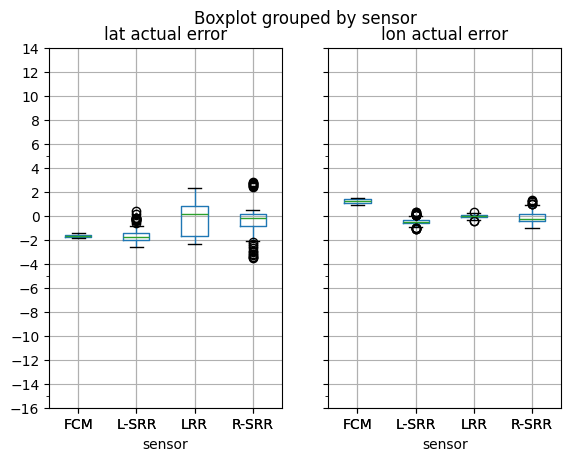

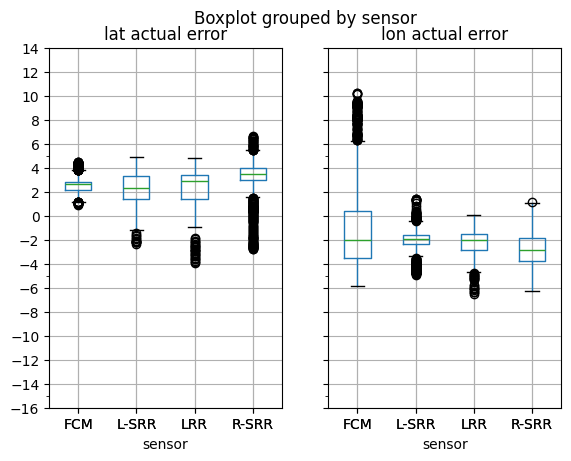

In [376]:
df_calibrated4.boxplot(column=['lat actual error','lon actual error'], by='sensor')
plt.yticks(range(-16,16,2))
plt.ylabel("Error(m)")
df_subset.boxplot(column=['lat actual error','lon actual error'], by='sensor')
plt.yticks(range(-16,16,2))
plt.ylabel("Error(m)")

In [377]:
print_stats("Raw",df_RSRR)
print()
print_stats("Cal4",df_RSRR_cal4)

Raw Lat Actual Error Mean: 3.2110855613627907
Raw Lat Actual Error STDEV: 1.489660813268895
Raw Lat Actual Error Median: 3.509010720819175
Raw Lat Actual Error Min: -2.791530364931006
Raw Lat Actual Error Max: 6.65758926633784
Raw Lon Actual Error Mean: -2.8816321769528144
Raw Lat Actual Error STDEV: 1.2290563769856384
Raw Lon Actual Error Median: -2.8793438465558
Raw Lon Actual Error Min: -6.3013889811286
Raw Lon Actual Error Max: 1.1334934318291996
Raw Lat_Vel Actual Error Mean: -0.2714965952052286
Raw Lat_Vel Actual Error STDEV: 1.0676994554955777
Raw Lat_Vel Actual Error Median: -0.05383802015054018
Raw Lat_Vel Actual Error Min: -5.4198433706132
Raw Lat_Vel Actual Error Max: 2.30781960339076
Raw Lon_Vel Actual Error Mean: 0.028666963592545256
Raw Lon_Vel Actual Error STDEV: 0.48150865881985333
Raw Lon_Vel Actual Error Median: 0.061161214616349824
Raw Lon_Vel Actual Error Min: -2.25700007746049
Raw Lon_Vel Actual Error Max: 4.22792564539543

Cal4 Lat Actual Error Mean: -0.3962842068

Text(0, 0.5, 'Error(m)')

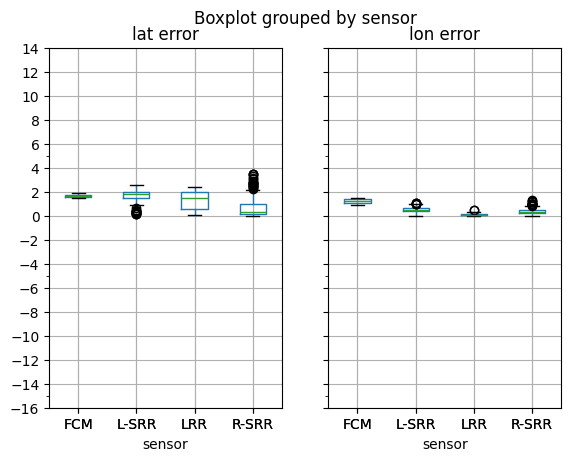

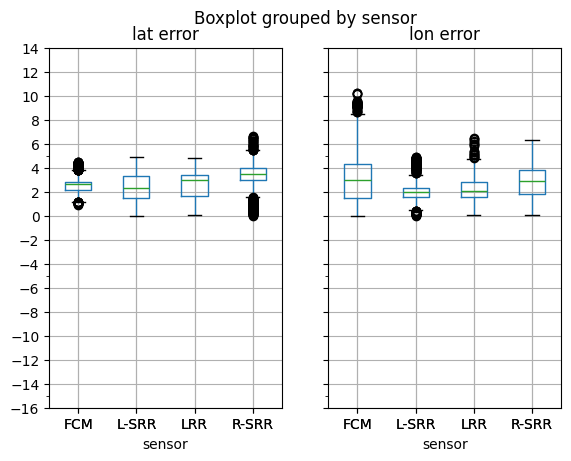

In [378]:
df_calibrated4.boxplot(column=['lat error','lon error'], by='sensor')
plt.yticks(range(-16,16,2))
plt.ylabel("Error(m)")
df_subset.boxplot(column=['lat error','lon error'], by='sensor')
plt.yticks(range(-16,16,2))
plt.ylabel("Error(m)")

# Calibrated 5

In [430]:
df_calibrated_RightToLeft = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc1/sc1_RightToLeft_filtered_calibrated.csv")
df_calibrated_RightToCloseTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc3/sc3_RightToCloseTurn_filtered_calibrated.csv")
df_calibrated_LeftToCloseTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc4/sc4_LeftToCloseTurn_filtered_calibrated.csv")
# df_calibrated_LeftToFarTurn = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc5/sc5_LeftToFarTurnFilteredCalibrated_Process.csv")
# df_calibrated_FromFront = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc6/sc6_FromFrontFilteredCalibrated_Process.csv")
# df_calibrated_FromFrontLeft = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc7/sc7_FromFrontLeftFilteredCalibrated_Process.csv")
# df_calibrated = pd.concat([df_calibrated_RightToLeft, df_calibrated_RightToCloseTurn,df_calibrated_LeftToCloseTurn, df_calibrated_LeftToFarTurn, df_calibrated_FromFront, df_calibrated_FromFrontLeft])
df_calibrated5 = pd.concat([df_calibrated_RightToLeft, df_calibrated_RightToCloseTurn, df_calibrated_LeftToCloseTurn])

df_calibrated_RightToLeft_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc1/sc1_RightToLeft_fusion_calibrated.csv")
df_calibrated_RightToCloseTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc3/sc3_RightToCloseTurn_fusion_calibrated.csv")
df_calibrated_LeftToCloseTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc4/sc4_LeftToCloseTurn_fusion_calibrated.csv")
# df_calibrated_LeftToFarTurn_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc5/sc5_LeftToFarTurnFusionCalibrated.csv")
# df_calibrated_FromFront_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc6/sc6_FromFrontFusionCalibrated.csv")
# df_calibrated_FromFrontLeft_fused = pd.read_csv("/home/yz4d3h/Documents/vspy6-10-25/sc7/sc7_FromFrontLeftFusionCalibrated.csv")
# df_calibrated_fused = pd.concat([df_calibrated_RightToLeft_fused, df_calibrated_RightToCloseTurn,df_calibrated_LeftToCloseTurn, df_calibrated_LeftToFarTurn_fused, df_calibrated_FromFront_fused, df_calibrated_FromFrontLeft_fused])
df_calibrated5_fused = pd.concat([df_calibrated_RightToLeft_fused, df_calibrated_RightToCloseTurn_fused, df_calibrated_LeftToCloseTurn_fused])
colors = [' ', [1,0,0],[0,0,1],[0,1,0],[1,0,1]]
markers = ['.', 'o', '^', 's', 'P','p','1','*','+','x','D']
group = [' ',"LRR", "FCM", "L-SRR", "R-SRR"]

df_calibrated5["marker"] = df_calibrated5.apply(lambda x: markers[x["sensor_id"]], axis=1)
df_calibrated5["sensor"] = df_calibrated5.apply(lambda x: group[x["sensor_id"]], axis=1)
df_calibrated5["color"] = df_calibrated5.apply(lambda x: colors[x["sensor_id"]], axis=1)
filtered_df_lat = df_calibrated5[df_calibrated5['lat error'] > 20]
filtered_df_lon = df_calibrated5[df_calibrated5['lon error'] > 30]

df_calibrated5['lat actual error'] = df_calibrated5['lat offset from ego (m)'] - df_calibrated5['interpolated ground truth x in m']
df_calibrated5['lon actual error'] = df_calibrated5['lon offset from ego (m)'] - df_calibrated5['interpolated ground truth y in m']
df_calibrated5['lat_vel actual error'] = df_calibrated5['lat_vel w.r.t ego (m/s)'] - df_calibrated5['interpolated x velocity in m/s']
df_calibrated5['lon_vel actual error'] = df_calibrated5['lon_vel w.r.t. ego (m/s)'] - df_calibrated5['interpolated y velocity in m/s']


df_calibrated5_fused['lat actual error'] = df_calibrated5_fused['Lat'] - df_calibrated5_fused['GT Lat']
df_calibrated5_fused['lon actual error'] = df_calibrated5_fused['Lon'] - df_calibrated5_fused['GT Lon']
df_calibrated5_fused['lat_vel actual error'] = df_calibrated5_fused['Lat_Vel'] - df_calibrated5_fused['GT Lat_Vel']
df_calibrated5_fused['lon_vel actual error'] = df_calibrated5_fused['Lon_Vel'] - df_calibrated5_fused['GT Lon_Vel']



In [431]:
print_stats("df",df_fusion_subset)
print("****************************************")
print_stats("df_cal", df_calibrated5_fused)

df Lat Actual Error Mean: -3.9299484487179486
df Lat Actual Error STDEV: 0.5554612076967026
df Lat Actual Error Median: -3.9353369999999988
df Lat Actual Error Min: -4.984905000000001
df Lat Actual Error Max: -1.705490000000001
df Lon Actual Error Mean: -2.8891698888888886
df Lat Actual Error STDEV: 0.4005766930961755
df Lon Actual Error Median: -2.9322799999999987
df Lon Actual Error Min: -3.805036000000001
df Lon Actual Error Max: -1.7755360000000007
df Lat_Vel Actual Error Mean: -0.07632633760683759
df Lat_Vel Actual Error STDEV: 0.8770797665625454
df Lat_Vel Actual Error Median: -0.013964500000000157
df Lat_Vel Actual Error Min: -3.2835579999999993
df Lat_Vel Actual Error Max: 2.1354439999999997
df Lon_Vel Actual Error Mean: 0.04391502991452992
df Lon_Vel Actual Error STDEV: 0.31537766933950884
df Lon_Vel Actual Error Median: 0.04130750000000001
df Lon_Vel Actual Error Min: -1.0618340000000002
df Lon_Vel Actual Error Max: 0.8390150000000001
****************************************


In [432]:
test1 = df_subset[df_subset['object_type'] == False]
test3 = df_calibrated5[df_calibrated5['object_type'] == False]

Text(0, 0.5, 'Error(m)')

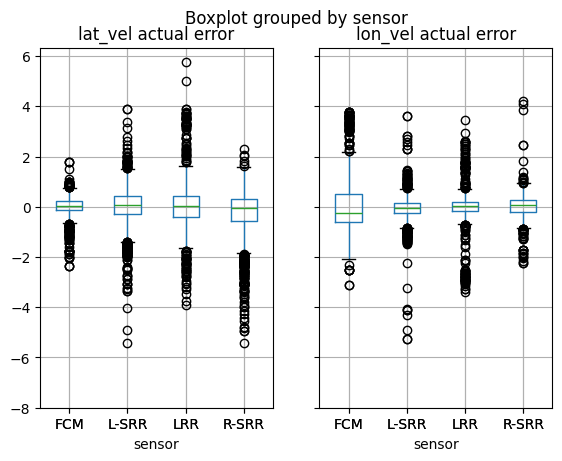

In [433]:
test1.boxplot(column=['lat_vel actual error','lon_vel actual error'], by='sensor')
plt.yticks(range(-8,8,2))
plt.ylabel("Error(m)")

Text(0, 0.5, 'Error(m)')

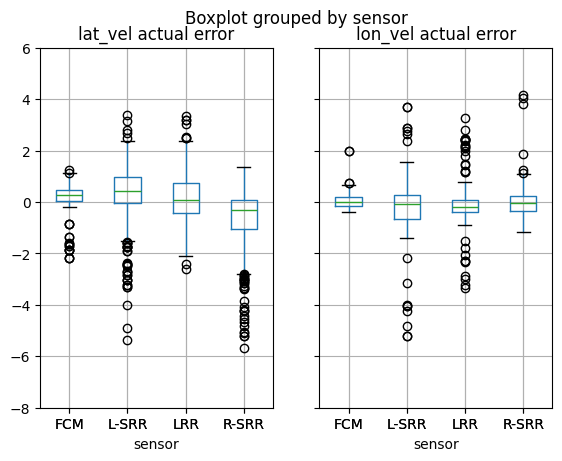

In [434]:
test3.boxplot(column=['lat_vel actual error','lon_vel actual error'], by='sensor')
plt.yticks(range(-8,8,2))
plt.ylabel("Error(m)")

In [435]:
df_LRR_cal5 = test3[test3['sensor'] == 'LRR']
# Temp to fix a stupid error where I flipped a sign in the cals, its been fixed but it is easier to fix post than to rerun the data
# Yes this does mean the fusion data is technically wrong but its close enough
#df_LRR_cal5['lat_vel actual error'] = df_LRR_cal5['lat_vel actual error'] - (2 * 0.9417774655697115)

df_LSRR_cal5 = test3[test3['sensor'] == 'L-SRR']
df_RSRR_cal5 = test3[test3['sensor'] == 'R-SRR']
df_FCM_cal5 = test3[test3['sensor'] == 'FCM']

test3 = pd.concat([df_LRR_cal5, df_LSRR_cal5, df_RSRR_cal5, df_FCM_cal5])

In [436]:
print_stats("Raw",df_RSRR)
print()
print_stats("Cal4",df_RSRR_cal5)

Raw Lat Actual Error Mean: 3.2110855613627907
Raw Lat Actual Error STDEV: 1.489660813268895
Raw Lat Actual Error Median: 3.509010720819175
Raw Lat Actual Error Min: -2.791530364931006
Raw Lat Actual Error Max: 6.65758926633784
Raw Lon Actual Error Mean: -2.8816321769528144
Raw Lat Actual Error STDEV: 1.2290563769856384
Raw Lon Actual Error Median: -2.8793438465558
Raw Lon Actual Error Min: -6.3013889811286
Raw Lon Actual Error Max: 1.1334934318291996
Raw Lat_Vel Actual Error Mean: -0.2714965952052286
Raw Lat_Vel Actual Error STDEV: 1.0676994554955777
Raw Lat_Vel Actual Error Median: -0.05383802015054018
Raw Lat_Vel Actual Error Min: -5.4198433706132
Raw Lat_Vel Actual Error Max: 2.30781960339076
Raw Lon_Vel Actual Error Mean: 0.028666963592545256
Raw Lon_Vel Actual Error STDEV: 0.48150865881985333
Raw Lon_Vel Actual Error Median: 0.061161214616349824
Raw Lon_Vel Actual Error Min: -2.25700007746049
Raw Lon_Vel Actual Error Max: 4.22792564539543

Cal4 Lat Actual Error Mean: -0.1752237582

Text(0, 0.5, 'Error(m)')

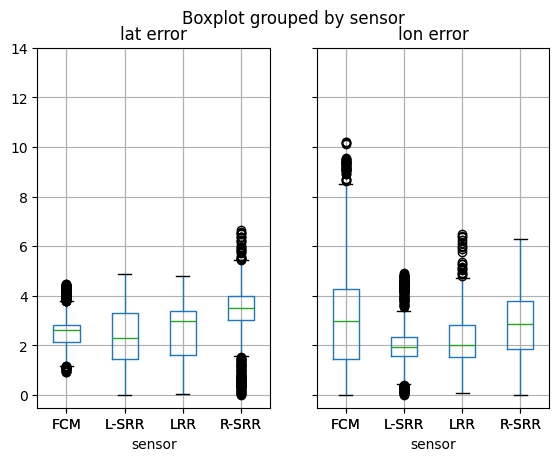

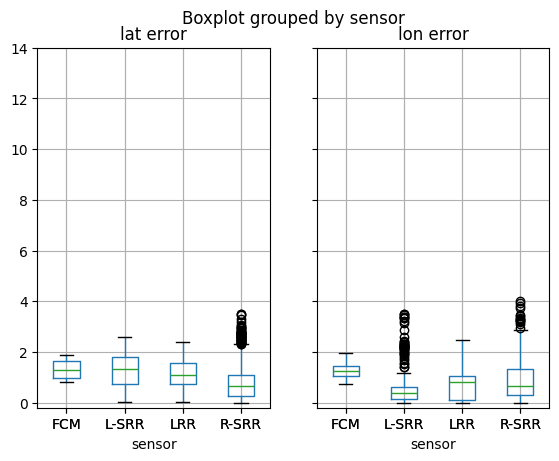

In [445]:
df_subset.boxplot(column=['lat error','lon error'], by='sensor')
plt.yticks(range(0,16,2))
plt.ylabel("Error(m)")
df_calibrated5.boxplot(column=['lat error','lon error'], by='sensor')
plt.yticks(range(0,16,2))
plt.ylabel("Error(m)")

In [442]:
print_stats_fusion("Pre Calibration Absolute", df_fusion_subset)

Pre Calibration Absolute Lat Error Mean: 3.929948444444444
Pre Calibration Absolute Lat Error STDEV: 0.5554612156515268
Pre Calibration Absolute Lat Error Median: 3.935337
Pre Calibration Absolute Lat Error Min: 1.70549
Pre Calibration Absolute Lat Error Max: 4.984905
Pre Calibration Absolute Lon Error Mean: 2.889169991452991
Pre Calibration Absolute Lon Error STDEV: 0.4005767164204168
Pre Calibration Absolute Lon Error Median: 2.9322795
Pre Calibration Absolute Lon Error Min: 1.775536
Pre Calibration Absolute Lon Error Max: 3.805037
Pre Calibration Absolute Lat_Vel Error Mean: 0.6181879145299146
Pre Calibration Absolute Lat_Vel Error STDEV: 0.6255583823888632
Pre Calibration Absolute Lat_Vel Error Median: 0.42028350000000003
Pre Calibration Absolute Lat_Vel Error Min: 0.004056
Pre Calibration Absolute Lat_Vel Error Max: 3.283558
Pre Calibration Absolute Lon_Vel Error Mean: 0.2529161111111111
Pre Calibration Absolute Lon_Vel Error STDEV: 0.19276612530969917
Pre Calibration Absolute Lon

In [439]:
print_stats_fusion("Post Calibration Absolute", df_calibrated5_fused)

Post Calibration Absolute Lat Error Mean: 0.898143378091873
Post Calibration Absolute Lat Error STDEV: 0.7321122035288277
Post Calibration Absolute Lat Error Median: 0.6885325
Post Calibration Absolute Lat Error Min: 0.003656
Post Calibration Absolute Lat Error Max: 3.281116
Post Calibration Absolute Lon Error Mean: 0.7359535212014136
Post Calibration Absolute Lon Error STDEV: 0.7356181814343168
Post Calibration Absolute Lon Error Median: 0.4563215
Post Calibration Absolute Lon Error Min: 0.000118
Post Calibration Absolute Lon Error Max: 3.617563
Post Calibration Absolute Lat_Vel Error Mean: 0.6416291554770318
Post Calibration Absolute Lat_Vel Error STDEV: 0.5918950430985738
Post Calibration Absolute Lat_Vel Error Median: 0.479937
Post Calibration Absolute Lat_Vel Error Min: 0.001656
Post Calibration Absolute Lat_Vel Error Max: 3.477117
Post Calibration Absolute Lon_Vel Error Mean: 0.42445561484098937
Post Calibration Absolute Lon_Vel Error STDEV: 0.5521091040281836
Post Calibration Ab

In [459]:
print_stats("", df_fusion_subset)

 Lat Actual Error Mean: -3.93
 Lat Actual Error STDEV: 0.56
 Lat Actual Error Median: -3.94

 Lon Actual Error Mean: -2.89
 Lat Actual Error STDEV: 0.40
 Lon Actual Error Median: -2.93

 Lat_Vel Actual Error Mean: -0.08
 Lat_Vel Actual Error STDEV: 0.88
 Lat_Vel Actual Error Median: -0.01

 Lon_Vel Actual Error Mean: 0.04
 Lon_Vel Actual Error STDEV: 0.32
 Lon_Vel Actual Error Median: 0.04


In [460]:
print_stats("", df_calibrated5_fused)

 Lat Actual Error Mean: -0.40
 Lat Actual Error STDEV: 1.09
 Lat Actual Error Median: -0.30

 Lon Actual Error Mean: -0.40
 Lat Actual Error STDEV: 0.96
 Lon Actual Error Median: -0.33

 Lat_Vel Actual Error Mean: -0.10
 Lat_Vel Actual Error STDEV: 0.87
 Lat_Vel Actual Error Median: -0.09

 Lon_Vel Actual Error Mean: -0.03
 Lon_Vel Actual Error STDEV: 0.70
 Lon_Vel Actual Error Median: -0.04


# Presentation Plotting

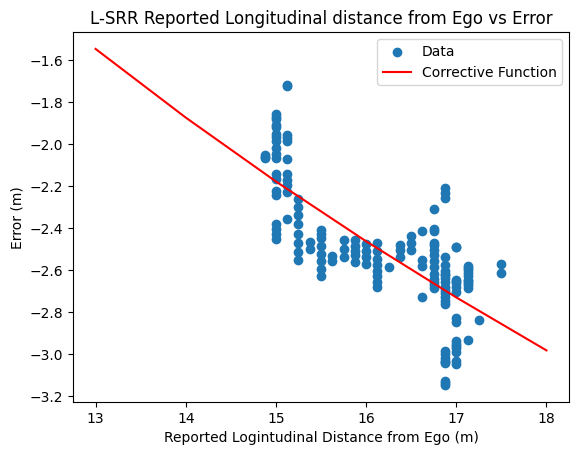

In [1094]:
selected = test1[test1['sensor'] =='L-SRR']
col1 = 'lon offset from ego (m)'
#col1 = 'lat_vel w.r.t ego (m/s)'
col2 = 'lon actual error'
def func(x, a, b):
    return a * np.log(x) + b
popt, pcov = curve_fit(func, selected[col1], selected[col2])
plt.scatter(selected[col1], selected[col2], label='Data')
plt.plot(range(int(selected[col1].min())-1,int(selected[col1].max())+2), func(range(int(selected[col1].min())-1,int(selected[col1].max())+2), *popt), 'r-', label='Corrective Function')
plt.legend()
plt.title('L-SRR Reported Longitudinal distance from Ego vs Error')
plt.xlabel('Reported Logintudinal Distance from Ego (m)')
plt.ylabel('Error (m)')
plt.show()

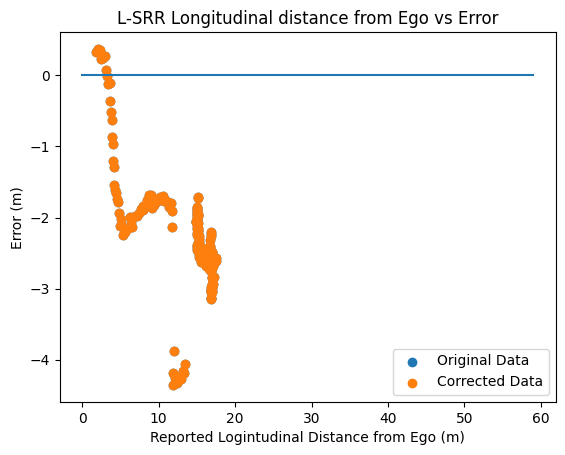

In [1171]:
selected = test1[test1['sensor'] =='L-SRR']
col1 = 'lon offset from ego (m)'
#col1 = 'lat_vel w.r.t ego (m/s)'
col2 = 'lon actual error'
plt.scatter(selected[col1], selected[col2], label='Original Data')
plt.scatter(df_LSRR_cal5[col1],df_LSRR_cal5[col2], label='Corrected Data')
plt.plot(range(0,60),[0]*60)
plt.legend()
plt.title('L-SRR Longitudinal distance from Ego vs Error')
plt.xlabel('Reported Logintudinal Distance from Ego (m)')
plt.ylabel('Error (m)')
plt.show()

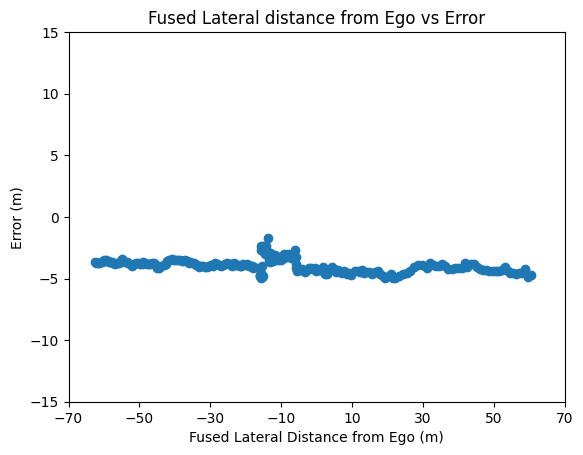

In [1096]:
selected = df_fusion_subset
plt.scatter(selected['Lat'], selected['lat actual error'])
plt.title('Fused Lateral distance from Ego vs Error')
plt.xlabel('Fused Lateral Distance from Ego (m)')
plt.ylabel('Error (m)')
plt.yticks(range(-15,16,5))
plt.xticks(range(-70,71,20))
plt.show()

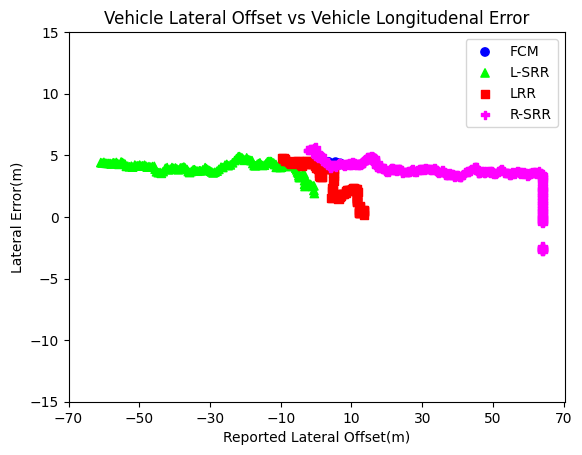

In [1097]:
i = 0
for sensor, d in df_subset.groupby('sensor'):
    i+=1
    marker = markers[i]
    #if sensor != "R-SRR":
    #    continue
    plt.scatter(x=d['lat offset from ego (m)'], y=d['lat actual error'], c=d['color'], marker=marker, label=sensor)
plt.yticks(range(-15,16,5))
plt.xticks(range(-70,71,20))
plt.xlabel("Reported Lateral Offset(m)")
plt.ylabel("Lateral Error(m)")
plt.title("Vehicle Lateral Offset vs Vehicle Longitudenal Error")
plt.legend()

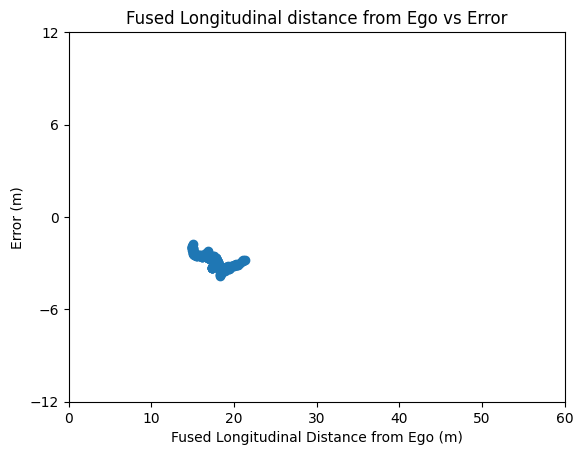

In [1098]:
selected = df_fusion_subset
plt.scatter(selected['Lon'], selected['lon actual error'])
plt.yticks(range(-12,14,6))
plt.xticks(range(0,70,10))
plt.title('Fused Longitudinal distance from Ego vs Error')
plt.xlabel('Fused Longitudinal Distance from Ego (m)')
plt.ylabel('Error (m)')
plt.show()

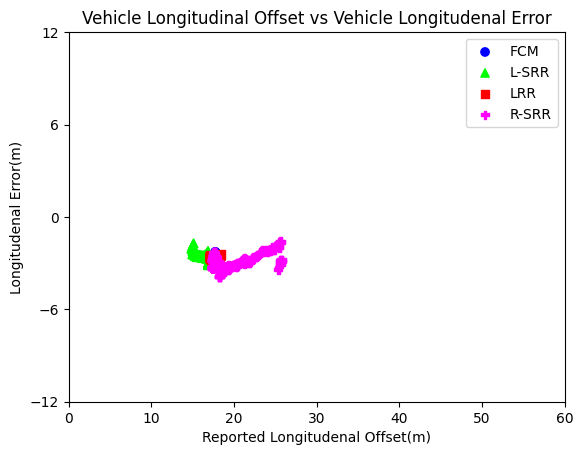

In [1099]:
i = 0
for sensor, d in df_subset.groupby('sensor'):
    i+=1
    marker = markers[i]
    #if sensor != "R-SRR":
    #    continue
    plt.scatter(x=d['lon offset from ego (m)'], y=d['lon actual error'], c=d['color'], marker=marker, label=sensor)
plt.yticks(range(-12,14,6))
plt.xticks(range(0,70,10))
plt.xlabel("Reported Longitudenal Offset(m)")
plt.ylabel("Longitudenal Error(m)")
plt.title("Vehicle Longitudinal Offset vs Vehicle Longitudenal Error")
plt.legend()

Text(0.5, 1.0, 'Un-Calibrated Fused Lateral Velocity Error')

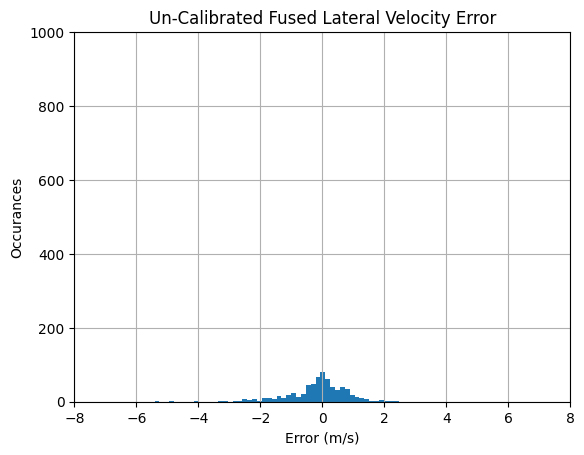

In [1100]:
test1.hist(column="lat_vel actual error", bins=50)
plt.xlabel("Error (m/s)")
plt.ylabel("Occurances")
plt.xticks(range(-8,9,2))
plt.yticks(range(0,1001,200))
plt.title("Un-Calibrated Fused Lateral Velocity Error")

Text(0.5, 1.0, 'Calibrated Fused Lateral Velocity Error')

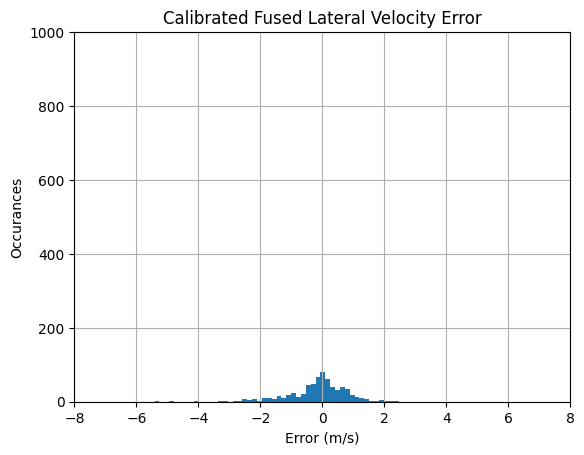

In [1101]:
test3.hist(column="lat_vel actual error", bins=50)
plt.xlabel("Error (m/s)")
plt.xticks(range(-8,9,2))
plt.yticks(range(0,1001,200))
plt.ylabel("Occurances")
plt.title("Calibrated Fused Lateral Velocity Error")

In [1102]:
print_stats("",df_subset)

 Lat Actual Error Mean: 3.577076973606931
 Lat Actual Error STDEV: 1.3126399053761737
 Lat Actual Error Median: 3.8935003079662973
 Lat Actual Error Min: -2.791530364931006
 Lat Actual Error Max: 5.6222739548406
 Lon Actual Error Mean: -2.8220882346272433
 Lon Actual Error STDEV: 0.4055637974487414
 Lon Actual Error Median: -2.7817818770318006
 Lon Actual Error Min: -3.8941310768381996
 Lon Actual Error Max: -1.5987466153814012
 Lat_Vel Actual Error Mean: -0.14591364630158069
 Lat_Vel Actual Error STDEV: 0.9613666442129725
 Lat_Vel Actual Error Median: -0.03362996979118016
 Lat_Vel Actual Error Min: -5.4158940878289
 Lat_Vel Actual Error Max: 2.45579402437098
 Lon_Vel Actual Error Mean: 0.04351114051745976
 Lon_Vel Actual Error STDEV: 0.37621930558732897
 Lon_Vel Actual Error Median: 0.047261547434610404
 Lon_Vel Actual Error Min: -1.155806988442881
 Lon_Vel Actual Error Max: 0.9392442032086961
